# <span style = "color:green"> Data Aggregation and Preparation </span>

### Step 1: Download the IEEE 118-Bus System

methodology citation: Donti, P., Amos, B., & Kolter, J. Z. (2017). Task-based End-to-End Model Learning in Stochastic Optimization. Advances in Neural Information Processing Systems (NeurIPS), 30. (This paper is foundational for bridging neural network load predictions directly with downstream non-linear grid optimization).

In [1]:
import urllib.request
import pandas as pd
import re

# 1. Download the file
url = "https://raw.githubusercontent.com/power-grid-lib/pglib-opf/master/pglib_opf_case118_ieee.m"
filename = "pglib_opf_case118_ieee.m"
print("Downloading IEEE 118-bus case...")
urllib.request.urlretrieve(url, filename)

def parse_matpower_matrix(filepath, matrix_name):
    with open(filepath, 'r') as f:
        content = f.read()
    
    # Use regex to find the block of text between 'mpc.matrix_name = [' and '];'
    pattern = rf"mpc\.{matrix_name}\s*=\s*\[(.*?)\];"
    match = re.search(pattern, content, re.DOTALL)
        
    data = []
    # Read line by line, ignoring MATLAB comments (%)
    for line in match.group(1).strip().split('\n'):
        # Strip comments, remove MATLAB semicolons, and clean whitespace
        clean_line = line.split('%')[0].replace(';', '').strip()
            
        row = [float(x) for x in clean_line.split()]
        data.append(row)
        
    return pd.DataFrame(data)

# =====================================================================
# 3. EXTRACT THE DC-OPF DATA
# =====================================================================

# --- BUS DATA ---
# Col 0: Bus ID | Col 2: Active Demand (Pd) in MW
bus_df = parse_matpower_matrix(filename, 'bus')
nodal_demand = bus_df[[0, 2]].rename(columns={0: 'bus_id', 2: 'Pd_mw'})

# --- GENERATOR DATA (WITH FIXED ALPHAS) ---
# Col 0: Bus ID | Col 1: Base Pg | Col 8: Pmax (MW) | Col 9: Pmin (MW)
gen_df = parse_matpower_matrix(filename, 'gen')
gen_limits = gen_df[[0, 1, 8, 9]].rename(columns={
    0: 'bus_id', 
    1: 'Pg_base_mw', 
    8: 'Pmax_mw', 
    9: 'Pmin_mw'
})

# 1. Calculate available headroom for each generator
gen_limits['headroom_mw'] = gen_limits['Pmax_mw'] - gen_limits['Pg_base_mw']

# 2. Safety clip: Ensure no negative headroom (in case of MATPOWER rounding quirks)
gen_limits['headroom_mw'] = gen_limits['headroom_mw'].clip(lower=0.0)

# 3. Calculate the fixed alpha (Participation Factor)
total_headroom = gen_limits['headroom_mw'].sum()

if total_headroom > 0:
    gen_limits['alpha_fixed'] = gen_limits['headroom_mw'] / total_headroom
else:
    # Fallback if no headroom exists system-wide (unlikely in standard cases)
    gen_limits['alpha_fixed'] = 1.0 / len(gen_limits)

print("Fixed Alpha values calculated successfully. Top 5 contributors:")
print(gen_limits[['bus_id', 'Pg_base_mw', 'Pmax_mw', 'alpha_fixed']].sort_values('alpha_fixed', ascending=False).head())

# --- BRANCH DATA ---
# Col 0: From Bus | Col 1: To Bus | Col 3: Reactance (x) | Col 5: Rate A (MW limit)
branch_df = parse_matpower_matrix(filename, 'branch')
branch_data = branch_df[[0, 1, 3, 5]].rename(columns={0: 'from_bus', 1: 'to_bus', 3: 'x_reactance', 5: 'thermal_limit_mw'})

# Calculate Susceptance (B = 1/x) for your DC-OPF B-matrix
branch_data['B_susceptance'] = 1.0 / branch_data['x_reactance']

# --- GENERATOR COSTS ---
# Col 3: Number of coefficients | Col 5: Linear cost (c1) | Col 6: Constant cost (c0)
# Note: PGLib 118 uses linear costs, so n=2 (represented by 2 coefficients)
gencost_df = parse_matpower_matrix(filename, 'gencost')
gen_costs = gencost_df[[5, 6]].rename(columns={5: 'cost_linear', 6: 'cost_constant'})

print("Extraction Successful! Here is a sample of your branch data:")
print(branch_data.head())

Fixed Alpha values calculated successfully. Top 5 contributors:
    bus_id  Pg_base_mw  Pmax_mw  alpha_fixed
29    69.0       591.0   1182.0     0.181427
28    66.0       392.0    784.0     0.120338
44   100.0       326.5    653.0     0.100230
39    89.0       318.5    637.0     0.097774
36    80.0       254.5    509.0     0.078127
Extraction Successful! Here is a sample of your branch data:
   from_bus  to_bus  x_reactance  thermal_limit_mw  B_susceptance
0       1.0     2.0      0.09990             151.0      10.010010
1       1.0     3.0      0.04240             151.0      23.584906
2       4.0     5.0      0.00798             176.0     125.313283
3       3.0     5.0      0.10800             175.0       9.259259
4       5.0     6.0      0.05400             176.0      18.518519


### 2. Download Demand Data

citation: A novel probabilistic gradient boosting model withmulti-approachfeature selection and iterative seasonal trend decomposition for short-term load forecasting
Priyesh Saini∗, S.K. Parida

In [3]:
import pandas as pd
import numpy as np
import requests
import io
import time

START = "2019-01-01"
END   = "2020-01-01"

# CAISO system load is replaced by ARPA-E PERFORM NYISO data — see spatial demand cell below.
if False:
    from gridstatus import CAISO
    iso = CAISO()
    load = iso.get_load(
        start=pd.Timestamp(START, tz="US/Pacific"),
        end=pd.Timestamp(END,   tz="US/Pacific"),
    )
    load = load.rename(columns={"Load": "load_mw", "Time": "timestamp"})
    load["timestamp"] = (pd.to_datetime(load["timestamp"])
                          .dt.tz_convert("US/Pacific")
                          .dt.tz_localize(None))
    load["timestamp"] = load["timestamp"].dt.round("5min")
    load = (load[["timestamp", "load_mw"]]
            .drop_duplicates("timestamp")
            .sort_values("timestamp")
            .set_index("timestamp"))

# =====================================================================
# JFK ASOS: Chunked 5-minute temperature + RH (2019)
# =====================================================================
def fetch_asos_chunk(start_dt, end_dt, retries=5):
    """Fetches a small time chunk from IEM with automatic exponential backoff."""
    url = (
        "https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py"
        f"?station=JFK&data=tmpf,relh"
        f"&year1={start_dt.year}&month1={start_dt.month}&day1={start_dt.day}"
        f"&year2={end_dt.year}&month2={end_dt.month}&day2={end_dt.day}"
        "&tz=America/New_York&format=onlycomma&latlon=no&missing=empty"
    )
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

    for attempt in range(retries):
        response = requests.get(url, headers=headers)
        if response.status_code == 200:
            return pd.read_csv(io.StringIO(response.text), parse_dates=["valid"])
        elif response.status_code in [503, 429]:
            wait_time = 2 ** (attempt + 1) + 2
            print(f"  [!] HTTP {response.status_code}. Retrying in {wait_time}s...")
            time.sleep(wait_time)
        else:
            response.raise_for_status()

    raise Exception(f"Failed to fetch {start_dt.date()} after {retries} retries.")

print("Fetching JFK weather data (2019) in 30-day chunks...")

date_chunks = pd.date_range(start=START, end=END, freq='30D').tolist()
if pd.Timestamp(END) not in date_chunks:
    date_chunks.append(pd.Timestamp(END))

wx_chunks = []
for i in range(len(date_chunks) - 1):
    s = date_chunks[i]
    e = date_chunks[i+1]
    print(f"  -> Pulling chunk: {s.date()} to {e.date()}")
    chunk_df = fetch_asos_chunk(s, e)
    wx_chunks.append(chunk_df)
    time.sleep(3)

wx = pd.concat(wx_chunks, ignore_index=True)
wx = wx.drop_duplicates(subset=["valid"])
wx = wx.rename(columns={"valid": "timestamp", "tmpf": "temp_f", "relh": "rh_pct"})
wx["temperature"] = (wx["temp_f"] - 32) * 5/9

T  = wx["temperature"]
RH = wx["rh_pct"]
wx["humidity"] = (6.112 * np.exp(17.67 * T / (T + 243.5)) * RH * 2.1674) / (273.15 + T)

wx = wx[["timestamp", "temperature", "humidity"]].dropna()
wx["timestamp"] = wx["timestamp"].dt.round("5min")
wx = wx.groupby("timestamp").mean().sort_index()

# Align to fixed 2019 annual 5-min grid
grid = pd.date_range(start="2019-01-01", end="2019-12-31 23:55", freq="5min")
wx = wx.reindex(grid).interpolate("time", limit=12)

print(f"\nWeather rows (JFK 2019): {len(wx.dropna()):,}")

Fetching JFK weather data (2019) in 30-day chunks...
  -> Pulling chunk: 2019-01-01 to 2019-01-31
  -> Pulling chunk: 2019-01-31 to 2019-03-02
  -> Pulling chunk: 2019-03-02 to 2019-04-01
  -> Pulling chunk: 2019-04-01 to 2019-05-01
  -> Pulling chunk: 2019-05-01 to 2019-05-31
  -> Pulling chunk: 2019-05-31 to 2019-06-30
  -> Pulling chunk: 2019-06-30 to 2019-07-30
  -> Pulling chunk: 2019-07-30 to 2019-08-29
  -> Pulling chunk: 2019-08-29 to 2019-09-28
  -> Pulling chunk: 2019-09-28 to 2019-10-28
  -> Pulling chunk: 2019-10-28 to 2019-11-27
  -> Pulling chunk: 2019-11-27 to 2019-12-27
  -> Pulling chunk: 2019-12-27 to 2020-01-01

Weather rows (JFK 2019): 105,094


### 3. Data Aggregation and Scaling

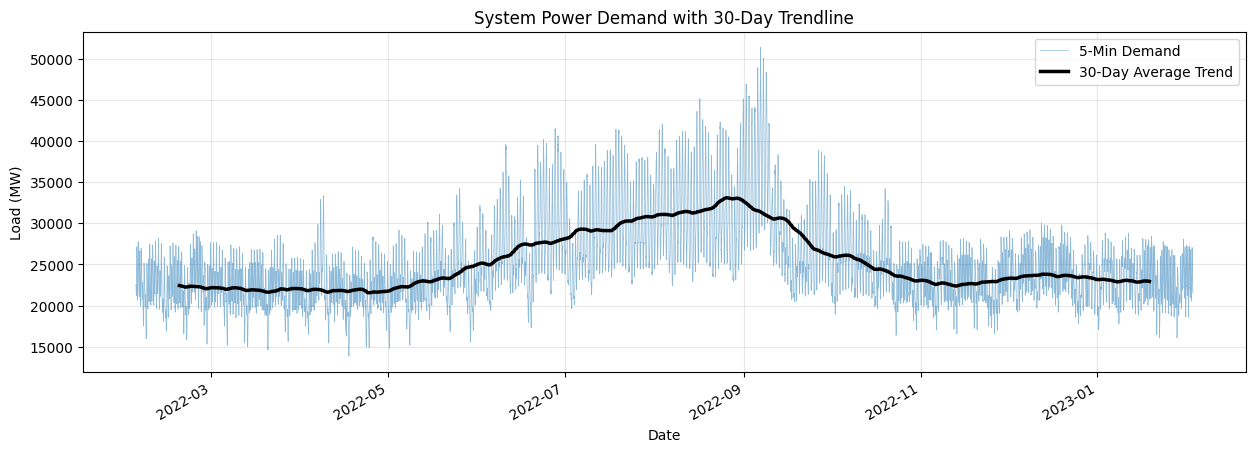

In [ ]:
import matplotlib.pyplot as plt

'''# 1. Calculate the 30-day rolling average
# 30 days = 30 * 288 (5-min intervals per day) = 8640
rolling_30d = df['load_mw'].rolling(window=8640, center=True).mean()

# 2. Plotting
plt.figure(figsize=(15, 5))

# Plot the raw 5-minute demand (made slightly transparent to let the trendline pop)
df['load_mw'].plot(
    color='#1f77b4', 
    linewidth=0.5, 
    alpha=0.5, 
    label='5-Min Demand'
)

# Plot the 30-Day Rolling Average Trendline
rolling_30d.plot(
    color='black',       # Strong contrasting color 
    linewidth=2.5,       # Thicker line to stand out over the blue density
    label='30-Day Average Trend'
)

# Format the chart
plt.title('System Power Demand with 30-Day Trendline')
plt.ylabel('Load (MW)')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right') # Adds a key to identify the lines

plt.show()'''

In [5]:
# df and scaling_factor are now built by the NYISO PERFORM spatial demand cell below.
# This cell is kept only for backward compatibility with CAISO-mode runs.
abs_max_scale = gen_limits['Pmax_mw'].sum() / nodal_demand['Pd_mw'].sum()

if 'load' in globals() and hasattr(load, 'index'):
    # CAISO legacy mode
    df = load.join(wx, how="inner").dropna()
    median_load = float(np.median(df['load_mw']))
    df['scaling_factor'] = df['load_mw'] / median_load
    exceedance_pct = (df['scaling_factor'] >= abs_max_scale).mean() * 100
    print(f"{exceedance_pct:.2f}% of time more power than gen can handle")
else:
    print("CAISO data not loaded — df will be built by the NYISO PERFORM cell.")

CAISO data not loaded — df will be built by the NYISO PERFORM cell.


In [6]:
## Identify Generator limits (system wide)
system_max = gen_limits['Pmax_mw'].sum()

safety_thresh = 1.06
max_scaling_factor = safety_thresh * system_max / nodal_demand['Pd_mw'].sum()
current_peak = df['scaling_factor'].max()

if current_peak > max_scaling_factor:
    rescale_factor = max_scaling_factor / current_peak
    df['scaling_factor'] = df['scaling_factor'] * rescale_factor

In [7]:
exceedance_pct = sum(df['scaling_factor'] >= abs_max_scale) / len(df['scaling_factor']) * 100
print(f"{exceedance_pct:.2f}% of time more power than gen can handle post adjustment")

0.37% of time more power than gen can handle post adjustment


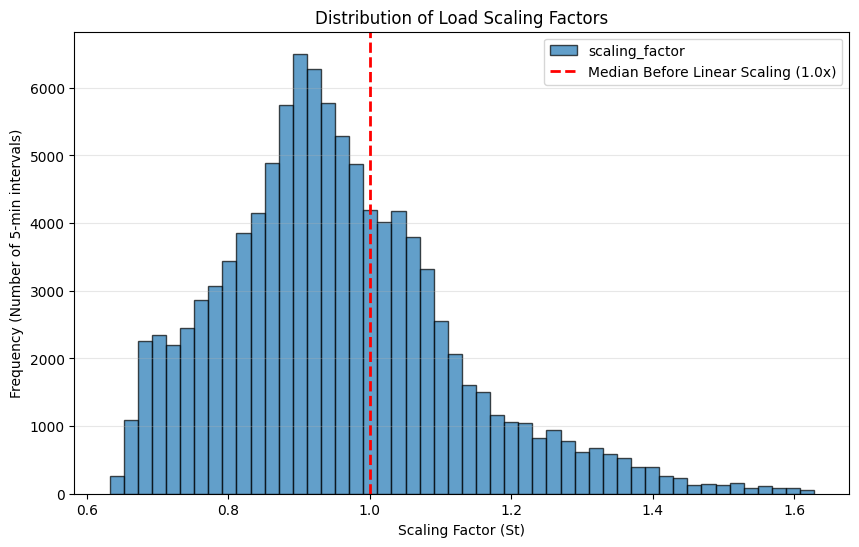

In [9]:
import matplotlib.pyplot as plt

### Plot scaling factors as this is
data = df['scaling_factor']
plt.figure(figsize=(10, 6))

# Plot the histogram with 50 bins for a clean resolution
df['scaling_factor'].plot.hist(
    bins=50, 
    color='#1f77b4',      # Standard blue
    edgecolor='black',    # Adds borders to the bars so they don't blur together
    alpha=0.7             # Slight transparency
)

# Add a red dashed line exactly at the mean (1.0)
plt.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Median Before Linear Scaling (1.0x)')

# Format the chart
plt.title('Distribution of Load Scaling Factors')
plt.xlabel('Scaling Factor (St)')
plt.ylabel('Frequency (Number of 5-min intervals)')
plt.grid(True, alpha=0.3, axis='y') # Only grid the y-axis for cleaner look
plt.legend()

plt.show()

In [10]:
# =============================================================================
# NYISO PERFORM Spatial Demand Model
#
# Replaces the homogeneous np.outer scaling with spatially-diverse 11-zone load.
# Each IEEE 118-bus cluster follows the temporal pattern of its assigned NYISO
# zone instead of all buses moving in lockstep.
#
# Pipeline:
#   1. Load all 11 NYISO zone HDF5 files from local cache (PERFORM schema).
#   2. Filter to calendar year 2019 (NYC local time), align to 5-min grid.
#   3. Spectral-cluster 118 buses into 11 groups on the susceptance-weighted
#      adjacency; assign clusters → zones by load-rank pairing.
#   4. Disaggregate: bus_load(t) = base_demand[b] × zone_scaling[t, zone_of_b].
#   5. Apply capacity-feasibility rescale (peak ≤ 95 % of gen capacity).
#   6. Rebuild df (load_mw, scaling_factor) and inner-join with wx.
# =============================================================================
import os, warnings
import numpy as np
import pandas as pd
import h5py
from sklearn.cluster import SpectralClustering

PERFORM_CACHE = "./perform_cache"
os.makedirs(PERFORM_CACHE, exist_ok=True)

# ── 1. Locate zone files (local cache first, then PERFORM S3) ─────────────────
_local_files = sorted(
    f for f in os.listdir(PERFORM_CACHE)
    if (f.startswith("NYISO_") or f.startswith("Zone_")) and f.endswith(".h5")
)

if _local_files:
    print(f"Found {len(_local_files)} local PERFORM cache files:")
    for f in _local_files:
        print(f"  {f}")
    h5_paths = [os.path.join(PERFORM_CACHE, f) for f in _local_files]
else:
    print("No local cache — downloading from ARPA-E PERFORM S3...")
    try:
        import s3fs
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "s3fs",
                               "--break-system-packages", "-q"])
        import s3fs

    fs = s3fs.S3FileSystem(anon=True)
    PREFIX = "arpa-e-perform/NYISO/2019/Load/Actuals/Zone_level"
    try:
        s3_paths = sorted(p for p in fs.ls(PREFIX) if p.endswith(".h5"))
        print(f"S3 listing: {len(s3_paths)} files")
        for p in s3_paths:
            print(f"  {os.path.basename(p)}")
    except Exception as e_ls:
        print(f"  fs.ls() failed ({e_ls}); using fallback zone list")
        _KNOWN = ["West", "Genesee", "Central", "North", "Mohawk_Valley",
                  "Capital", "Hudson_Valley", "Millwood", "Dunwoodie",
                  "N.Y.C.", "Long_Island"]
        s3_paths = [f"{PREFIX}/Zone_{z}_load_actuals_2019.h5" for z in _KNOWN]

    h5_paths = []
    for s3p in s3_paths:
        local_f = os.path.join(PERFORM_CACHE, os.path.basename(s3p))
        if not os.path.exists(local_f):
            print(f"  Downloading {os.path.basename(s3p)}...")
            fs.get(s3p, local_f)
        h5_paths.append(local_f)


# ── 2. Parse HDF5 files → zone timeseries ─────────────────────────────────────
zone_series = {}
for local_path in h5_paths:
    fname = os.path.basename(local_path)
    with h5py.File(local_path, "r") as f:
        actuals   = f["actuals"][:].ravel().astype(float)
        raw_times = f["time_index"][:].astype(str)
        # Zone name: 'meta' field (NYISO_* files) or derive from filename
        if "meta" in f:
            zone_name = f["meta"][0, 0].decode().strip()
        else:
            zone_name = (fname
                         .replace("Zone_", "")
                         .replace("_load_actuals_2019.h5", "")
                         .replace("NYISO_", "")
                         .replace("_load_2019.h5", ""))

    # Timestamps stored as UTC nanosecond ISO strings
    ts_utc = pd.to_datetime(raw_times, utc=True)
    ts_nyc = ts_utc.tz_convert("America/New_York").tz_localize(None)

    # Filter to calendar year 2019 (NYC local time)
    mask = ts_nyc.year == 2019
    zone_series[zone_name] = pd.Series(actuals[mask], index=ts_nyc[mask], name=zone_name)


# ── 3. Build aligned zonal DataFrame ──────────────────────────────────────────
zonal_df = pd.DataFrame(zone_series).sort_index()
zonal_df.index = zonal_df.index.round("5min")
zonal_df = zonal_df.groupby(zonal_df.index).mean().dropna(how="all")

print(f"\nzonal_df.shape:   {zonal_df.shape}")
print(f"zonal_df columns: {list(zonal_df.columns)}")


# ── 4. Spectral clustering: N_BUS buses → N_ZONES clusters ───────────────────
N_ZONES = zonal_df.shape[1]
print(f"\nSpectral clustering: {N_BUS} buses → {N_ZONES} clusters...")

# Susceptance-weighted adjacency matrix
A = np.zeros((N_BUS, N_BUS))
for b_i, (fi, ti) in enumerate(zip(from_idx, to_idx)):
    A[fi, ti] += B_line[b_i]
    A[ti, fi] += B_line[b_i]

# Affinity floor: keeps the graph Laplacian well-conditioned
A_aff = A + 1e-6 * (1.0 - np.eye(N_BUS))

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sc = SpectralClustering(
        n_clusters=N_ZONES,
        affinity="precomputed",
        assign_labels="kmeans",
        random_state=42,
        n_init=20,
    )
    bus_cluster = sc.fit_predict(A_aff)

cluster_sizes = np.bincount(bus_cluster)
print("Cluster size distribution:")
for ci, sz in enumerate(cluster_sizes):
    print(f"  Cluster {ci:2d}: {sz:3d} buses")


# ── 5. Assign clusters → NYISO zones by load rank ────────────────────────────
_BASE_BUS_raw = nodal_demand.set_index("bus_id").loc[bus_ids, "Pd_mw"].values.astype(float)

zone_medians = zonal_df.median().sort_values(ascending=False)
zone_rank    = zone_medians.index.tolist()          # zone names: highest median load first

cluster_base = np.array([_BASE_BUS_raw[bus_cluster == c].sum() for c in range(N_ZONES)])
cluster_rank = np.argsort(-cluster_base)            # cluster indices: largest base demand first

cluster_to_zone = {int(cluster_rank[i]): zone_rank[i] for i in range(N_ZONES)}

print("\nCluster → NYISO zone assignment (load-rank pairing):")
for cid, zname in sorted(cluster_to_zone.items()):
    print(f"  Cluster {cid:2d}  ({cluster_sizes[cid]:3d} buses, "
          f"base = {cluster_base[cid]:6.1f} MW)  →  {zname:12s}  "
          f"(NYISO median = {float(zone_medians[zname]):7.1f} MW)")


# ── 6. Spatial disaggregation ─────────────────────────────────────────────────
# zone_scaling[t, z] = zone_load(t) / median(zone_load_z)   (dimensionless, ≈1)
zone_scaling = zonal_df.div(zonal_df.median(), axis=1)   # shape: (T_nyiso, N_ZONES)

# bus_load(t) = base_demand[b] × zone_scaling[t, zone_of_b]
scaled_cols = {}
for b_i, b_id in enumerate(bus_ids):
    c      = int(bus_cluster[b_i])
    z_name = cluster_to_zone[c]
    scaled_cols[int(b_id)] = _BASE_BUS_raw[b_i] * zone_scaling[z_name]

scaled_nodal_raw = pd.DataFrame(scaled_cols, index=zonal_df.index)


# ── 7. Capacity-feasibility rescale ───────────────────────────────────────────
gen_cap        = float(gen_limits["Pmax_mw"].sum())
safety_target  = 0.95 * gen_cap
system_load_ts = scaled_nodal_raw.sum(axis=1)
peak_demand    = float(system_load_ts.max())

if peak_demand > safety_target:
    cap_rescale      = safety_target / peak_demand
    scaled_nodal_raw = scaled_nodal_raw * cap_rescale
    system_load_ts   = system_load_ts   * cap_rescale
    print(f"\nCapacity rescale applied: {peak_demand:.0f} MW → "
          f"{float(system_load_ts.max()):.0f} MW  (95% of {gen_cap:.0f} MW cap)")
else:
    cap_rescale = 1.0
    print(f"\nNo rescale needed: peak {peak_demand:.0f} MW ≤ {safety_target:.0f} MW (95% cap)")


# ── 8. Rebuild df and inner-join with weather ─────────────────────────────────
median_sys = float(system_load_ts.median())
df_base = pd.DataFrame({
    "load_mw":        system_load_ts,
    "scaling_factor": system_load_ts / median_sys,
})
df = df_base.join(wx, how="inner")

# Align scaled_nodal_demand to df's (weather-filtered) timestamps
scaled_nodal_demand = scaled_nodal_raw.reindex(df.index)

print(f"\ndf.shape:                  {df.shape}")
print(f"scaled_nodal_demand.shape: {scaled_nodal_demand.shape}")
print(f"df columns:                {list(df.columns)}")


# ── 9. Sanity checks ──────────────────────────────────────────────────────────
b1_id  = int(bus_ids[0])
b60_id = int(bus_ids[59])
corr_v = scaled_nodal_demand[b1_id].corr(scaled_nodal_demand[b60_id])
same_c = bool(bus_cluster[0] == bus_cluster[59])

print(f"\nSanity  bus {b1_id:3d} vs bus {b60_id:3d}:  corr = {corr_v:.4f}  "
      f"({'same cluster' if same_c else 'different clusters'}; "
      f"was 1.0000 under homogeneous scaling)")
print(f"Peak total demand : {df['load_mw'].max():,.1f} MW")
print(f"Gen capacity (sum): {gen_cap:,.1f} MW")
print(f"Peak / cap ratio  : {df['load_mw'].max() / gen_cap:.4f}  (target ≤ 0.95)")

Found 11 local PERFORM cache files:
  NYISO_A_load_2019.h5
  NYISO_B_load_2019.h5
  NYISO_C_load_2019.h5
  NYISO_D_load_2019.h5
  NYISO_E_load_2019.h5
  NYISO_F_load_2019.h5
  NYISO_G_load_2019.h5
  NYISO_H_load_2019.h5
  NYISO_I_load_2019.h5
  NYISO_J_load_2019.h5
  NYISO_K_load_2019.h5

zonal_df.shape:   (105048, 11)
zonal_df columns: ['WEST', 'GENESE', 'CENTRL', 'NORTH', 'MHK VL', 'CAPTIL', 'HUD VL', 'MILLWD', 'DUNWOD', 'N.Y.C.', 'LONGIL']

Spectral clustering: 118 buses → 11 clusters...
Cluster size distribution:
  Cluster  0:  16 buses
  Cluster  1:  12 buses
  Cluster  2:  12 buses
  Cluster  3:  14 buses
  Cluster  4:  10 buses
  Cluster  5:   9 buses
  Cluster  6:  10 buses
  Cluster  7:   7 buses
  Cluster  8:   7 buses
  Cluster  9:  14 buses
  Cluster 10:   7 buses

Cluster → NYISO zone assignment (load-rank pairing):
  Cluster  0  ( 16 buses, base =  458.0 MW)  →  WEST          (NYISO median =  1684.0 MW)
  Cluster  1  ( 12 buses, base =  381.0 MW)  →  CAPTIL        (NYISO 

# <span style = "color:green"> Define Our Two Stage Optimization Problem </span>

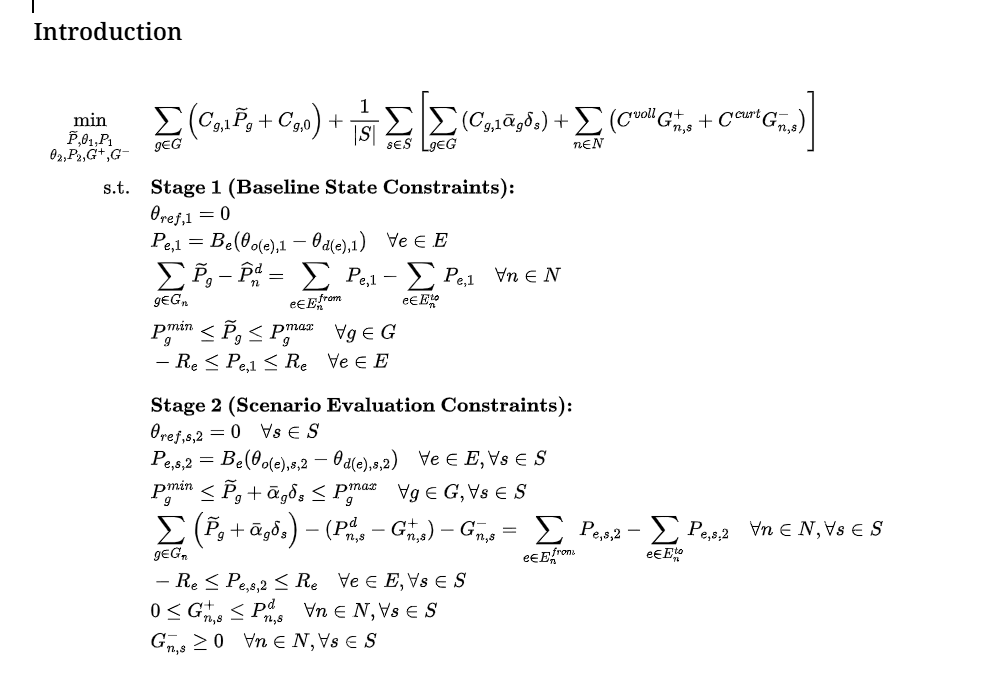

In [11]:
 ## Define Parameters
import numpy as np
import pandas as pd
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

# -----------------------------------------------------------------------------
# 1. Build index maps and system data
# -----------------------------------------------------------------------------
bus_ids   = nodal_demand['bus_id'].astype(int).values
N_BUS     = len(bus_ids)
bus_idx   = {int(b): i for i, b in enumerate(bus_ids)}

gen_bus     = gen_limits['bus_id'].astype(int).values
gen_bus_idx = np.array([bus_idx[int(b)] for b in gen_bus])
Pg_min      = gen_limits['Pmin_mw'].values
Pg_max      = gen_limits['Pmax_mw'].values
c1          = gen_costs['cost_linear'].values
c0          = gen_costs['cost_constant'].values
N_GEN       = len(gen_bus)
from_idx = np.array([bus_idx[int(b)] for b in branch_data['from_bus']])
to_idx   = np.array([bus_idx[int(b)] for b in branch_data['to_bus']])
B_line   = branch_data['B_susceptance'].values
R_line   = branch_data['thermal_limit_mw'].values
N_LINE   = len(B_line)

SLACK  = 0
VOLL   = 10000.0
C_CURT = 1000.0

In [12]:
# =============================================================================
# Two-Stage Stochastic DC-OPF — RHS UPDATED FAST CLASS
# =============================================================================
import numpy as np
import scipy.sparse as sp
import gurobipy as gp
from gurobipy import GRB

# ----- Sparse incidence matrices (built once, reused per solve) -----
# Generator-to-bus map: G_bus[n, g] = 1 iff generator g sits on bus n.
_G_bus_sp = sp.csr_matrix(
    (np.ones(N_GEN), (gen_bus_idx, np.arange(N_GEN))),
    shape=(N_BUS, N_GEN),
)
# Line incidence: A_inc[e, n] = +1 if line e leaves bus n, -1 if it enters.
_A_inc_sp = sp.csr_matrix(
    (
        np.concatenate([np.ones(N_LINE), -np.ones(N_LINE)]),
        (
            np.concatenate([np.arange(N_LINE), np.arange(N_LINE)]),
            np.concatenate([from_idx, to_idx]),
        ),
    ),
    shape=(N_LINE, N_BUS),
)
# Susceptance-weighted incidence so DC flow is just B_inc @ theta.
_B_inc_sp = sp.diags(B_line) @ _A_inc_sp

class FastStochasticOPF:
    """
    Persistent Gurobi model. Builds the massive Stage 1 and Stage 2 matrix exactly
    once. Allows instantaneous updates to demand parameters via .RHS and .UB.
    """
    def __init__(self, N_SCEN, voll=VOLL, c_curt=C_CURT, weights=None, verbose=False, return_lmps=False):
        self.N_SCEN = N_SCEN
        self.return_lmps = return_lmps
        
        if weights is None:
            weights = np.full(N_SCEN, 1.0 / N_SCEN)
        self.weights = np.asarray(weights, dtype=float)

        m = gp.Model("stochastic_dcopf_piecewise_4tier_fast")
        m.Params.OutputFlag = 1 if verbose else 0
        m.Params.Threads   = 0
        m.Params.Presolve  = 2
        
        # --- NEW LOGIC: Smart Method Selection ---
        if N_SCEN == 1:
            # Grid Search (Tiny Matrix): Use Dual Simplex
            m.Params.Method = 1
        else:
            # Full Evaluation (Massive Matrix): Use Barrier without Crossover
            m.Params.Method = 2
            m.Params.Crossover = -1 if return_lmps else 0

        # --- Stage 1 variables ---
        self.Pg    = m.addMVar(N_GEN,  lb=Pg_min, ub=Pg_max,    name="Pg")
        theta1     = m.addMVar(N_BUS,  lb=-GRB.INFINITY,        name="theta1")
        Pe1        = m.addMVar(N_LINE, lb=-R_line, ub=R_line,   name="Pe1")
        self.shed1 = m.addMVar(N_BUS,  lb=0.0,                  name="shed1")
        self.curt1 = m.addMVar(N_BUS,  lb=0.0,                  name="curt1")

        # --- Stage 2 variables (UB for G_shed set dynamically later) ---
        self.G_shed = m.addMVar((N_SCEN, N_BUS), lb=0.0, ub=GRB.INFINITY, name="G_shed") 
        self.G_curt = m.addMVar((N_SCEN, N_BUS), lb=0.0,                  name="G_curt")
        theta2      = m.addMVar((N_SCEN, N_BUS), lb=-GRB.INFINITY,        name="theta2")
        Pe2         = m.addMVar((N_SCEN, N_LINE),
                                lb=np.tile(-R_line, (N_SCEN, 1)),
                                ub=np.tile( R_line, (N_SCEN, 1)),
                                name="Pe2")

        # 4-tier ramp block limits
        b1, b2, b3, b4 = 0.03 * Pg_max, 0.07 * Pg_max, 0.10 * Pg_max, 0.80 * Pg_max
        ub_b1, ub_b2, ub_b3, ub_b4 = np.tile(b1, (N_SCEN, 1)), np.tile(b2, (N_SCEN, 1)), np.tile(b3, (N_SCEN, 1)), np.tile(b4, (N_SCEN, 1))

        r_up_1 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b1, name="r_up_1")
        r_up_2 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b2, name="r_up_2")
        r_up_3 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b3, name="r_up_3")
        r_up_4 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b4, name="r_up_4")
        r_dn_1 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b1, name="r_dn_1")
        r_dn_2 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b2, name="r_dn_2")
        r_dn_3 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b3, name="r_dn_3")
        r_dn_4 = m.addMVar((N_SCEN, N_GEN), lb=0.0, ub=ub_b4, name="r_dn_4")

        sum_up = r_up_1 + r_up_2 + r_up_3 + r_up_4
        sum_dn = r_dn_1 + r_dn_2 + r_dn_3 + r_dn_4

        # --- Stage 1 constraints ---
        m.addConstr(theta1[SLACK] == 0, name="slack1")
        m.addConstr(Pe1 == _B_inc_sp @ theta1, name="dc_flow_1")
        
        # Save pointer to balance constraint so we can update its RHS
        self.bal1 = m.addConstr(
            _G_bus_sp @ self.Pg + self.shed1 - self.curt1 - _A_inc_sp.T @ Pe1 == np.zeros(N_BUS),
            name="balance1",
        )

        # --- Stage 2 constraints ---
        self.bal2_constrs = []
        for s in range(N_SCEN):
            m.addConstr(theta2[s, SLACK] == 0, name=f"slack2_{s}")
            m.addConstr(Pe2[s, :] == _B_inc_sp @ theta2[s, :], name=f"dc_flow_2_{s}")

            Pg_rt_s = self.Pg + sum_up[s, :] - sum_dn[s, :]
            m.addConstr(Pg_rt_s >= Pg_min, name=f"pg_lo_{s}")
            m.addConstr(Pg_rt_s <= Pg_max, name=f"pg_hi_{s}")

            # Algebraically identical: variables on LHS, constants (Demand) on RHS
            bal2_s = m.addConstr(
                _G_bus_sp @ Pg_rt_s + self.G_shed[s, :] - self.G_curt[s, :] - _A_inc_sp.T @ Pe2[s, :] == np.zeros(N_BUS),
                name=f"balance2_{s}",
            )
            self.bal2_constrs.append(bal2_s)

        # --- Objective ---
        safe_Pg_max = np.where(Pg_max == 0, 1.0, Pg_max)
        inv_pgmax   = 1.0 / safe_Pg_max 

        stage1_gen_cost   = c1 @ self.Pg + float(np.sum(c0))
        stage1_slack_cost = (10 * voll) * self.shed1.sum() + (10 * c_curt) * self.curt1.sum()
        stage1_cost       = stage1_gen_cost + stage1_slack_cost

        W = self.weights[:, None] 
        total_stage2_gen = (W * c1[None, :] * (sum_up - sum_dn)).sum()
        total_ramp = (
            (W * (1e3 * inv_pgmax[None, :]) * (r_up_1 + r_dn_1)).sum()
          + (W * (2e3 * inv_pgmax[None, :]) * (r_up_2 + r_dn_2)).sum()
          + (W * (1e4 * inv_pgmax[None, :]) * (r_up_3 + r_dn_3)).sum()
          + (W * (1e7 * inv_pgmax[None, :]) * (r_up_4 + r_dn_4)).sum()
        )
        total_shed_2 = voll   * (W * self.G_shed).sum()
        total_curt_2 = c_curt * (W * self.G_curt).sum()

        expected_stage2 = total_stage2_gen + total_ramp + total_shed_2 + total_curt_2
        m.setObjective(stage1_cost + expected_stage2, GRB.MINIMIZE)

        self.m = m

    def solve(self, Pd_hat, node_scen):
        """ Instantly updates the matrix memory and runs the barrier method. """
        # 1. Update Stage 1 Right-Hand Side
        self.bal1.RHS = Pd_hat
        
        # 2. Update Stage 2 Shed Bounds
        self.G_shed.UB = node_scen
        
        # 3. Update Stage 2 Right-Hand Side
        for s in range(self.N_SCEN):
            self.bal2_constrs[s].RHS = node_scen[s, :]

        # Gurobi executes immediately without rebuilding
        self.m.optimize()
        if self.m.Status != GRB.OPTIMAL:
            raise RuntimeError(f"Gurobi Status={self.m.Status}")

        LMP_1 = np.asarray(self.bal1.Pi) if self.return_lmps else None

        return {
            "Pg":          self.Pg.X,
            "shed1":       self.shed1.X,
            "curt1":       self.curt1.X,
            "shed":        self.G_shed.X,
            "curt":        self.G_curt.X,
            "total_cost":  self.m.ObjVal,
            "stage1_cost": float(c1 @ self.Pg.X + np.sum(c0)),
            "LMP_1":       LMP_1,
        }

# Wrapper for backward compatibility 
def optimization_model(Pd_hat, node_scen, voll=VOLL, c_curt=C_CURT,
                       verbose=True, return_lmps=False, weights=None):
    solver = FastStochasticOPF(node_scen.shape[0], voll, c_curt, weights, verbose, return_lmps)
    return solver.solve(Pd_hat, node_scen)

# <span style="color:green">Method 1: Predict Demand and Generate Scenarios from LogNormal Distribution</span>

##  Decide between lognormal and gamma distributions for scaling factor data

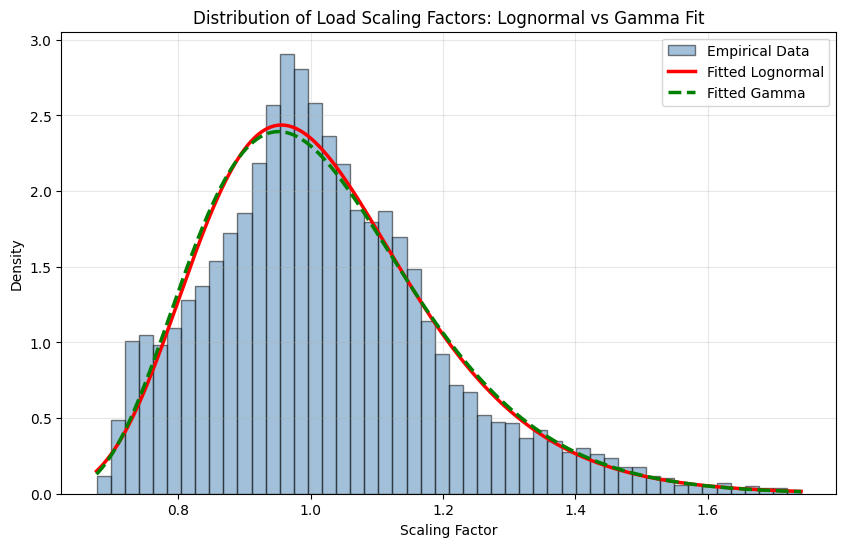

In [13]:
### Fit a distribution to the scaling factors
import scipy.stats as stats

# Assuming 'df' is your DataFrame and 'scaling_factor' is the column
# Drop any NaN values before fitting
data = df['scaling_factor'].dropna().values

shape_lognorm, loc_lognorm, scale_lognorm = stats.lognorm.fit(data)
shape_gamma, loc_gamma, scale_gamma = stats.gamma.fit(data)

x = np.linspace(data.min(), data.max(), 1000)
pdf_lognorm = stats.lognorm.pdf(x, shape_lognorm, loc_lognorm, scale_lognorm)
pdf_gamma = stats.gamma.pdf(x, shape_gamma, loc_gamma, scale_gamma)

# --- 4. Plot the Results ---
plt.figure(figsize=(10, 6))

# Plot the empirical histogram (must set density=True to match PDF scale)
plt.hist(data, bins=50, density=True, alpha=0.5, color='steelblue', edgecolor='black', label='Empirical Data')

# Overlay the fitted PDFs
plt.plot(x, pdf_lognorm, 'r-', lw=2.5, label='Fitted Lognormal')
plt.plot(x, pdf_gamma, 'g--', lw=2.5, label='Fitted Gamma')

plt.title('Distribution of Load Scaling Factors: Lognormal vs Gamma Fit')
plt.xlabel('Scaling Factor')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [14]:
# Calculate the negative log-likelihood (NLL) for both fits
# NLL is what scipy actually minimizes during the fit
nll_lognorm = stats.lognorm.nnlf((shape_lognorm, loc_lognorm, scale_lognorm), data)
nll_gamma = stats.gamma.nnlf((shape_gamma, loc_gamma, scale_gamma), data)

# Number of parameters (k) is 3 for both distributions (shape, loc, scale)
k = 3
n = len(data)

# Calculate AIC: AIC = 2k - 2*ln(L)  (where -ln(L) is the NLL)
aic_lognorm = 2 * k + 2 * nll_lognorm
aic_gamma = 2 * k + 2 * nll_gamma

print(f"Lognormal AIC: {aic_lognorm:.2f}")
print(f"Gamma AIC: {aic_gamma:.2f}")

if aic_lognorm < aic_gamma:
    print("The Lognormal distribution provides a better fit.")
else:
    print("The Gamma distribution provides a better fit.")

Lognormal AIC: -74909.75
Gamma AIC: -75138.34
The Gamma distribution provides a better fit.


In [15]:
### Generate the scenarios
num_samples = 100
scale_scenarios = stats.lognorm.rvs(shape_lognorm, loc=loc_lognorm, scale=scale_lognorm, size=num_samples)
nodes_to_mult = nodal_demand['Pd_mw']
node_scenarios = np.outer(scale_scenarios, nodes_to_mult)

In [16]:
from scipy.stats import lognorm
scaling_factor_hat = lognorm.mean(shape_lognorm, loc=loc_lognorm, scale=scale_lognorm)
Pn_d_hat = scaling_factor_hat * nodal_demand.set_index('bus_id')['Pd_mw']

In [17]:
# Align Pn_d_hat to bus order
if isinstance(Pn_d_hat, pd.Series):
    Pd_hat = np.array([Pn_d_hat[b] for b in bus_ids])
else:
    Pd_hat = np.asarray(Pn_d_hat)


node_scen = np.asarray(node_scenarios)
N_SCEN    = node_scen.shape[0]


## <span style = "color:green"> Run Two Stage Optimization Evaluation </span>

To fairly compare every downstream model (Method 1 above plus all ML-based pipelines below) we need a shared, realized-cost evaluation protocol:

1. **Train/test split (Option A — day-block stratified).** Hold out whole days sampled from every month of the CAISO year. Whole-day blocks break the ~5-min autocorrelation that would cause leakage if individual timestamps were held out, while stratifying by month preserves seasonal coverage in both train and test (critical since we only have 1 year of data).
2. **Realized stage-2 cost.** Given a stage-1 decision `(Pg*, α*)` solved under forecast `Pd_hat`, the actual demand `Pd_actual(t)` is revealed in the next 5-min window. The realized recourse cost comes from a *single-scenario* stage-2 LP with `Pg_applied = Pg* + α*·(Σ Pd_actual − Σ Pd_hat)` held fixed — optimizing only `θ, Pe, shed, curt, gen-limit-slack`.
3. **Evaluation loop.** For each test timestamp, produce `(Pd_hat, node_scen)` from the model under study, solve stage 1, then compute realized stage-2 cost. Total realized cost = stage-1 cost + realized stage-2 cost. Collect over N_TEST timestamps, report mean/std/CI.
4. **Shared test set.** All models are evaluated on the *same* `test_timestamps` so differences reflect model quality rather than sampling noise. This also enables paired comparisons later.

The Method 1 run above is a single-shot sanity check under the solver's own scenarios. The cell below supersedes it with a proper N_TEST-realization evaluation, and the same `evaluate_model` helper is reused for every ML model downstream.

In [18]:
## This Evaluation Code Can Be Shared Across All Models

import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import scipy.stats as stats

# -----------------------------------------------------------------------------
# 1. Train / test split (Option A: whole-day holdout, stratified by month)
# -----------------------------------------------------------------------------
DAYS_PER_MONTH_HELD_OUT = 4    # ~48 days of test pool → plenty to draw N_TEST from
N_TEST                  = 1000  # number of test timestamps used to evaluate each model
SPLIT_SEED              = 42

rng_split = np.random.default_rng(SPLIT_SEED)

_dates = df.index.normalize()
_all_dates = pd.Series(_dates.unique()).sort_values().reset_index(drop=True)

_test_dates = []
for (_y, _m), grp in _all_dates.groupby([_all_dates.dt.year, _all_dates.dt.month]):
    k = min(DAYS_PER_MONTH_HELD_OUT, len(grp))
    _test_dates.extend(rng_split.choice(grp.values, size=k, replace=False))
test_dates = pd.to_datetime(sorted(_test_dates))

_test_mask = pd.Series(_dates, index=df.index).isin(test_dates)
train_df   = df.loc[~_test_mask].copy()
test_df    = df.loc[ _test_mask].copy()

# Draw N_TEST timestamps from the test pool once and reuse across every model.
_test_idx      = rng_split.choice(len(test_df), size=N_TEST, replace=False)
test_timestamps = test_df.index[np.sort(_test_idx)]

print(f"Train rows: {len(train_df):,}  |  Test rows: {len(test_df):,}  |  "
      f"Held-out days: {len(test_dates)}  |  N_TEST: {len(test_timestamps)}")

# Align scaled_nodal_demand columns to bus_ids order (do once).
_nodal_by_bus = scaled_nodal_demand.reindex(columns=bus_ids)
assert not np.isnan(_nodal_by_bus.values).any()

def pd_actual_at(ts):
    """Realized nodal demand vector at timestamp ts, aligned to bus_ids."""
    return _nodal_by_bus.loc[ts].values.astype(float)

# -----------------------------------------------------------------------------
# 2. Realized stage-2 cost (single scenario, Pg/alpha fixed) — FAST CLASS
# -----------------------------------------------------------------------------
class FastRealizedStage2:
    def __init__(self, voll=VOLL, c_curt=C_CURT):
        m = gp.Model("stage2_realized_fast")
        m.Params.OutputFlag = 0
        m.Params.Method  = 1 # Dual simplex is perfect for this smaller LP
        m.Params.Threads = 1
        
        # --- Piecewise block limits ---
        b1_limit = 0.03 * Pg_max
        b2_limit = 0.07 * Pg_max
        b3_limit = 0.10 * Pg_max
        b4_limit = 0.80 * Pg_max

        self.r_up_1 = m.addMVar(N_GEN, lb=0.0, ub=b1_limit, name="r_up_1")
        self.r_up_2 = m.addMVar(N_GEN, lb=0.0, ub=b2_limit, name="r_up_2")
        self.r_up_3 = m.addMVar(N_GEN, lb=0.0, ub=b3_limit, name="r_up_3")
        self.r_up_4 = m.addMVar(N_GEN, lb=0.0, ub=b4_limit, name="r_up_4")
        self.r_dn_1 = m.addMVar(N_GEN, lb=0.0, ub=b1_limit, name="r_dn_1")
        self.r_dn_2 = m.addMVar(N_GEN, lb=0.0, ub=b2_limit, name="r_dn_2")
        self.r_dn_3 = m.addMVar(N_GEN, lb=0.0, ub=b3_limit, name="r_dn_3")
        self.r_dn_4 = m.addMVar(N_GEN, lb=0.0, ub=b4_limit, name="r_dn_4")

        # Note: UB for G_shed is set to INFINITY initially; we update it dynamically later
        self.G_shed = m.addMVar(N_BUS, lb=0.0, ub=GRB.INFINITY, name="G_shed")
        self.G_curt = m.addMVar(N_BUS, lb=0.0,                  name="G_curt")
        theta       = m.addMVar(N_BUS, lb=-GRB.INFINITY,        name="theta")
        Pe          = m.addMVar(N_LINE, lb=-R_line, ub=R_line,  name="Pe")

        sum_up = self.r_up_1 + self.r_up_2 + self.r_up_3 + self.r_up_4
        sum_dn = self.r_dn_1 + self.r_dn_2 + self.r_dn_3 + self.r_dn_4
        sum_net_ramp = sum_up - sum_dn

        # --- Vectorized constraints ---
        m.addConstr(theta[SLACK] == 0)
        m.addConstr(Pe == _B_inc_sp @ theta)
        
        # Generation limit constraints (Variables on LHS, Constants on RHS)
        self.pg_min_constr = m.addConstr(sum_net_ramp >= np.zeros(N_GEN)) 
        self.pg_max_constr = m.addConstr(sum_net_ramp <= np.zeros(N_GEN)) 
        
        # Power balance constraint
        self.bal_constr = m.addConstr(
            _G_bus_sp @ sum_net_ramp + self.G_shed - self.G_curt - _A_inc_sp.T @ Pe == np.zeros(N_BUS)
        )
        
        # --- Objective: identical to original ---
        safe_Pg_max = np.where(Pg_max == 0, 1.0, Pg_max)
        inv_pgmax   = 1.0 / safe_Pg_max

        ramp_cost = (
            (1e3 * inv_pgmax) @ (self.r_up_1 + self.r_dn_1)
          + (2e3 * inv_pgmax) @ (self.r_up_2 + self.r_dn_2)
          + (1e4 * inv_pgmax) @ (self.r_up_3 + self.r_dn_3)
          + (1e7 * inv_pgmax) @ (self.r_up_4 + self.r_dn_4)
        )
        stage2_gen_cost = c1 @ sum_net_ramp
        shed_cost = voll   * self.G_shed.sum()
        curt_cost = c_curt * self.G_curt.sum()

        m.setObjective(stage2_gen_cost + ramp_cost + shed_cost + curt_cost, GRB.MINIMIZE)
        self.m = m

    def solve(self, Pg_star, Pd_actual):
        # 1. Update Bound for Shedding
        self.G_shed.UB = Pd_actual
        
        # 2. Update RHS for generation limits
        self.pg_min_constr.RHS = Pg_min - Pg_star
        self.pg_max_constr.RHS = Pg_max - Pg_star
        
        # 3. Update RHS for power balance
        self.bal_constr.RHS = Pd_actual - (_G_bus_sp @ Pg_star)
        
        self.m.optimize()

        if self.m.Status not in [GRB.OPTIMAL, GRB.SUBOPTIMAL]:
            raise RuntimeError(f"Realized stage-2 did not solve, status={self.m.Status}")

        total_ramp = float(
            self.r_up_1.X.sum() + self.r_up_2.X.sum() + self.r_up_3.X.sum() + self.r_up_4.X.sum()
          + self.r_dn_1.X.sum() + self.r_dn_2.X.sum() + self.r_dn_3.X.sum() + self.r_dn_4.X.sum()
        )

        return {
            "stage2_cost": float(self.m.ObjVal),
            "shed":        float(self.G_shed.X.sum()),
            "curt":        float(self.G_curt.X.sum()),
            "total_ramp":  total_ramp,
            "delta":       float(Pd_actual.sum() - Pg_star.sum()),
        }


from tqdm import tqdm

def evaluate_model(name, predict_fn, test_timestamps, verbose_every=20):
    rows  = []
    cache = {}
    
    # Track the persistent Stage 1 solver
    fast_solver = None
    current_weights_key = None

    # Instantiate the Stage 2 solver once
    fast_stage2_solver = FastRealizedStage2(voll=VOLL, c_curt=C_CURT)

    for i, ts in tqdm(enumerate(test_timestamps), total=len(test_timestamps), desc=f"Eval {name}"):
        out = predict_fn(ts)
        if len(out) == 2:
            Pd_hat, node_scen = out
            weights = None
        else:
            Pd_hat, node_scen, weights = out

        wkey = None if weights is None else np.asarray(weights, dtype=float).tobytes()
        key = (Pd_hat.tobytes(), node_scen.tobytes(), wkey)
        
        if key not in cache:
            # Build the Gurobi matrix ONLY on the first pass (or if weights change)
            if fast_solver is None or wkey != current_weights_key:
                fast_solver = FastStochasticOPF(
                    N_SCEN=node_scen.shape[0], 
                    voll=VOLL, 
                    c_curt=C_CURT, 
                    weights=weights, 
                    verbose=False
                )
                current_weights_key = wkey
            
            # Solve the full two-stage stochastic OPF based on predictions
            r = fast_solver.solve(Pd_hat, node_scen)
            
            # Cache the optimal first-stage decision vector (Pg*)
            # Note: We discard r["stage1_cost"] here to avoid double-counting expected recourse
            cache[key] = r["Pg"].copy()
        
        # Retrieve the fixed decision vector from the cache
        Pg_star = cache[key]

        # Calculate the pure, deterministic Stage 1 generation cost (c1^T * Pg*)
        deterministic_s1_cost = float(c1 @ Pg_star)

        # Retrieve the actual/realized nodal demand for this timestamp
        Pd_actual = pd_actual_at(ts)
        
        # Evaluate Stage 2 cost using the fixed decision vector against the single realized scenario
        r2 = fast_stage2_solver.solve(Pg_star, Pd_actual)

        rows.append({
            "model":                name,
            "ts":                   ts,
            "stage1_cost":          deterministic_s1_cost,
            "stage2_cost_realized": r2["stage2_cost"],
            "total_realized":       deterministic_s1_cost + r2["stage2_cost"],
            "shed_mw":              r2["shed"],
            "curt_mw":              r2["curt"],
            "total_ramp_mw":        r2["total_ramp"],
            "delta_mw":             r2["delta"],
        })

    return pd.DataFrame(rows)

def summarize_results(results_df, alpha=0.05):
    from scipy.stats import t
    n     = len(results_df)
    mean  = results_df["total_realized"].mean()
    std   = results_df["total_realized"].std(ddof=1)
    tcrit = t.ppf(1 - alpha/2, df=n-1)
    half  = tcrit * std / np.sqrt(n)
    return pd.Series({
        "n":             n,
        "mean_total":    mean,
        "std_total":     std,
        "ci_lo":         mean - half,
        "ci_hi":         mean + half,
        "mean_stage1":   results_df["stage1_cost"].mean(),
        "mean_stage2":   results_df["stage2_cost_realized"].mean(),
        "mean_shed_mw":  results_df["shed_mw"].mean(),
        "mean_curt_mw":  results_df["curt_mw"].mean(),
        "mean_ramp_mw":  results_df["total_ramp_mw"].mean(),
        "frac_shed_gt1": (results_df["shed_mw"] > 1.0).mean(),
    })


Train rows: 91,224  |  Test rows: 13,824  |  Held-out days: 48  |  N_TEST: 1000


## Evaluate Model 1

In [19]:

# -----------------------------------------------------------------------------
# 4. Method 1 evaluation — lognormal fit on TRAIN ONLY (overrides earlier globals)
# -----------------------------------------------------------------------------
_train_sf = train_df["scaling_factor"].dropna().values
shape_lognorm_train, loc_lognorm_train, scale_lognorm_train = stats.lognorm.fit(_train_sf)

# Point prediction: mean of train-fit lognormal, scaled onto per-bus base demand.
_scale_hat_m1 = stats.lognorm.mean(shape_lognorm_train,
                                   loc_lognorm_train,
                                   scale_lognorm_train)
_base_bus     = nodal_demand.set_index("bus_id").loc[bus_ids, "Pd_mw"].values.astype(float)
Pd_hat_m1     = _scale_hat_m1 * _base_bus

# 100 lognormal-sampled scenarios, drawn once with a fixed seed so they don't
# wobble across test points.
_SCEN_SEED = 123
_scale_scen = stats.lognorm.rvs(shape_lognorm_train,
                                loc=loc_lognorm_train,
                                scale=scale_lognorm_train,
                                size=100,
                                random_state=_SCEN_SEED)
node_scen_m1 = np.outer(_scale_scen, _base_bus)

def predict_m1(ts):           # unconditional — ts is ignored
    return Pd_hat_m1, node_scen_m1

print("\n>>> Evaluating Method 1 (lognormal mean + lognormal scenarios) over test set...")
results_m1 = evaluate_model("M1_lognormal", predict_m1, test_timestamps)

print("\nMethod 1 summary:")
print(summarize_results(results_m1).to_string())

# Store results registry for downstream aggregation.
all_model_results = {"M1_lognormal": results_m1}



>>> Evaluating Method 1 (lognormal mean + lognormal scenarios) over test set...
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2810602
Academic license 2810602 - for non-commercial use only - registered to am___@columbia.edu


Eval M1_lognormal:   0%|          | 0/1000 [00:00<?, ?it/s]/var/folders/nn/n3_8rlvx6h9bxwg2t6d_0xth0000gn/T/ipykernel_74616/1379236281.py:110: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s + self.G_shed[s, :] - self.G_curt[s, :] - _A_inc_sp.T @ Pe2[s, :] == np.zeros(N_BUS),
Eval M1_lognormal: 100%|██████████| 1000/1000 [00:02<00:00, 379.49it/s]


Method 1 summary:
n                  1000.000000
mean_total       185369.626748
std_total        451390.847649
ci_lo            157358.709596
ci_hi            213380.543900
mean_stage1      111765.627216
mean_stage2       73603.999532
mean_shed_mw          4.071687
mean_curt_mw         36.649625
mean_ramp_mw        820.336982
frac_shed_gt1         0.017000


# <span style = "color:red"> Machine Learning Based Pipelines

## <span style="color:green"> Model 2: Conditional Mean (GBR) + Lognormal Residual Scenarios</span>

Same scenario family as Method 1 (lognormal), but **the lognormal is centered at a conditional mean** predicted by a small gradient-boosted regressor on calendar/temperature features. Mathematically: `scaling_factor = μ(features) · ε`, with `ε ~ Lognormal` fit once on training residuals. Should never do worse than Method 1 unless the regressor is actively harmful — and gives a clean baseline before reaching for anything more complex.


In [20]:
# =============================================================================
# Method 1b: Conditional Mean (GBR) + Lognormal Residual Scenarios
#
# Pipeline:
#   1. Fit GradientBoostingRegressor to predict scaling_factor on TRAIN.
#   2. Fit Lognormal to TRAIN multiplicative residuals (actual / predicted).
#   3. At test ts: scenario_t = μ(features_t) * ε,  ε ~ Lognormal(train_resid).
# =============================================================================
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import lognorm

# 1. Create the lags on the FULL continuous dataframe
# NOTE: lag_1 (t-5min) and lag_2 (t-10min) are intentionally excluded to
#       prevent near-future look-ahead leakage. Only lag_288 (same 5-min
#       block from the prior day) and longer lags are permitted.
df["sf_lag_288"] = df["scaling_factor"].shift(288) # Exact same 5-min block yesterday

# 2. Drop the rows that now have NaNs (the first 24 hours of your dataset)
df = df.dropna()

# ---> THE FIX: Re-align the indices to forget the deleted rows <---
train_df = train_df.loc[train_df.index.intersection(df.index)]
test_df = test_df.loc[test_df.index.intersection(df.index)]
test_timestamps = test_timestamps.intersection(df.index)

# 3. Update your feature list
FEATS = ["temperature_raw", "hour", "day_of_week", "day_of_month", 
         "week", "is_holiday", "sf_lag_288"]

# --- ensure features exist (cell 28 builds them, but Method 1b runs earlier) ---
if "temperature_raw" not in df.columns:
    df["temperature_raw"] = df["temperature"]
if "hour" not in df.columns:
    df["hour"]         = df.index.hour + df.index.minute / 60.0
    df["day_of_week"]  = df.index.dayofweek
    df["day_of_month"] = df.index.day
    df["week"]         = df.index.isocalendar().week.astype(int)
if "is_holiday" not in df.columns:
    try:
        import holidays as _holidays
        _us = _holidays.US(years=list(range(df.index.year.min(),
                                            df.index.year.max() + 1)))
        df["is_holiday"] = [1 if d.date() in _us else 0 for d in df.index]
    except ImportError:
        df["is_holiday"] = 0

_train_X = train_df[FEATS].values if all(f in train_df.columns for f in FEATS) \
           else df.loc[train_df.index, FEATS].values
_train_y = train_df["scaling_factor"].values

# 1) Conditional mean predictor
gbr = GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                learning_rate=0.05, random_state=0)
gbr.fit(_train_X, _train_y)

# 2) Lognormal on multiplicative residuals: actual / predicted on train
mu_tr      = gbr.predict(_train_X)
resid_mult = _train_y / mu_tr
sh_r, lo_r, sc_r = lognorm.fit(resid_mult, floc=0)
print(f"[M1b] Residual lognormal:  shape={sh_r:.4f}, scale={sc_r:.4f}")
print(f"[M1b] Train R^2 (sf):     {gbr.score(_train_X, _train_y):.4f}")

# 3) Scenario generator
_BASE_BUS    = nodal_demand.set_index("bus_id").loc[bus_ids, "Pd_mw"].values.astype(float)
_test_feats  = df.loc[test_df.index, FEATS]
_m1b_rng     = np.random.default_rng(2024)
N_SCEN_M1B   = 100

# --- 1. Pre-compute everything OUTSIDE the loop ---
# Get all predictions at once (Vectorized)
all_test_feats = df.loc[test_timestamps, FEATS].values
all_mu_preds = gbr.predict(all_test_feats)
mu_dict = {ts: mu for ts, mu in zip(test_timestamps, all_mu_preds)}

# Generate exactly 100 base residuals ONCE
eps_base = lognorm.rvs(sh_r, lo_r, sc_r, size=N_SCEN_M1B, random_state=_m1b_rng)

# --- 2. Simplify the function ---
def predict_m1b(ts):
    mu = mu_dict[ts] 
    
    # Broadcast the scalar mu across the 100 base residuals
    Pd_hat = mu * _BASE_BUS
    scen   = np.outer(mu * eps_base, _BASE_BUS)
    
    return Pd_hat, scen

# --- Evaluation ---
print("\n>>> Evaluating Method 1b (GBR mean + lognormal residual) over test set...")
results_m1b = evaluate_model("M1b_gbr_lognormal", predict_m1b, test_timestamps)

print("\nMethod 1b summary:")
print(summarize_results(results_m1b).to_string())

all_model_results["M1b_gbr_lognormal"] = results_m1b

[M1b] Residual lognormal:  shape=0.0285, scale=0.9993
[M1b] Train R^2 (sf):     0.9710

>>> Evaluating Method 1b (GBR mean + lognormal residual) over test set...


Eval M1b_gbr_lognormal:   0%|          | 0/1000 [00:00<?, ?it/s]/var/folders/nn/n3_8rlvx6h9bxwg2t6d_0xth0000gn/T/ipykernel_74616/1379236281.py:110: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s + self.G_shed[s, :] - self.G_curt[s, :] - _A_inc_sp.T @ Pe2[s, :] == np.zeros(N_BUS),
Eval M1b_gbr_lognormal: 100%|██████████| 1000/1000 [03:58<00:00,  4.19it/s]


Method 1b summary:
n                  1000.000000
mean_total       112125.368208
std_total        254149.369391
ci_lo             96354.208984
ci_hi            127896.527431
mean_stage1       98242.263765
mean_stage2       13883.104443
mean_shed_mw          2.464168
mean_curt_mw          1.331695
mean_ramp_mw        659.818725
frac_shed_gt1         0.012000


## <span style = "color:green"> Model 3: NGBoost (Covariate Aware Scenario Generation) </span> (Similar Performance to Model 2)

In [21]:
# from ngboost import NGBRegressor
# from ngboost.distns import LogNormal
# from sklearn.tree import DecisionTreeRegressor
# import numpy as np

# # =============================================================================
# # Method 2: Conditional Mean & Variance (NGBoost) + LogNormal Scenarios
# #
# # Pipeline:
# #   1. Train NGBRegressor (LogNormal) to predict scaling_factor on TRAIN.
# #   2. Pre-compute distribution parameters for the entire test set.
# #   3. Evaluate using the pre-computed parameters and static standard normal draws.
# # =============================================================================

# print("\n>>> Training Model 2 (NGBoost Conditional LogNormal)...")

# # --- 0. TRAINING PHASE ---
# # Setup the training features and target (matching your GBR setup)
# _train_X = train_df[FEATS].values if all(f in train_df.columns for f in FEATS) \
#            else df.loc[train_df.index, FEATS].values
# _train_y = train_df["scaling_factor"].values

# # Initialize the NGBoost model specifying LogNormal as the target distribution.
# # We use hyper-parameters similar to your GBR model for a fair comparison.
# ngb = NGBRegressor(
#     Dist=LogNormal,
#     Base=DecisionTreeRegressor(criterion='friedman_mse', max_depth=4),
#     n_estimators=300,
#     learning_rate=0.05,
#     random_state=2025
# )

# # Train the model
# ngb.fit(_train_X, _train_y)
# print("Training complete!")


# # --- 1. PRE-COMPUTE OUTSIDE THE LOOP ---
# # 2) Scenario generator (FAST SAA IMPLEMENTATION)
# N_SCEN_M2 = 100
# _m2_rng = np.random.default_rng(2025)

# # Draw standard normal variables ONCE
# Z_base_m2 = _m2_rng.standard_normal(N_SCEN_M2)

# # Get NGBoost distributions for the entire test set at ONCE
# all_test_feats_m2 = df.loc[test_timestamps, FEATS].values
# Y_dist_all_m2 = ngb.pred_dist(all_test_feats_m2)

# # Extract parameters into fast dictionaries
# m2_median_dict = {ts: val for ts, val in zip(test_timestamps, Y_dist_all_m2.params['scale'])}
# m2_sigma_dict  = {ts: val for ts, val in zip(test_timestamps, Y_dist_all_m2.params['s'])}

# # Ensure _BASE_BUS is defined (re-declaring just in case it's missing from scope)
# _BASE_BUS = nodal_demand.set_index("bus_id").loc[bus_ids, "Pd_mw"].values.astype(float)


# # --- 2. FAST PREDICT FUNCTION ---
# def predict_m2(ts):
#     # 1. Fast dict lookup
#     sf_median = float(m2_median_dict[ts])
#     sf_sigma  = float(m2_sigma_dict[ts])
    
#     # 2. Mathematical Order of Operations
#     mu_log  = np.log(sf_median)
#     sf_mean = np.exp(mu_log + (sf_sigma**2) / 2.0)
    
#     # 3. Point forecast using the TRUE MEAN
#     Pd_hat = sf_mean * _BASE_BUS
    
#     # 4. Draw dynamically scaled scenarios using the static Z_base
#     sf_scens = np.exp(mu_log + sf_sigma * Z_base_m2)
#     scen = np.outer(sf_scens, _BASE_BUS)
    
#     return Pd_hat, scen

# # --- 3. EVALUATION ---
# print("\n>>> Evaluating Model 2 (NGBoost Conditional LogNormal) over test set...")
# results_m2 = evaluate_model("M2_ngboost", predict_m2, test_timestamps)

# print("\nModel 2 summary:")
# print(summarize_results(results_m2).to_string())

# all_model_results["M2_ngboost"] = results_m2

## <span style = "color:green"> Model 4: Alpha Scaling Layer </span> (OLD)

In [22]:
# import numpy as np
# import pandas as pd
# from tqdm import tqdm

# # Wider grid: allows alpha to meaningfully deviate from 1.0 when covariates
# # indicate systematic over- or under-forecasting (e.g., hot afternoons vs.
# # mild overnight hours).  Finer resolution lets the meta-model learn sharper
# # decision boundaries.
# ALPHA_GRID = np.linspace(0.85, 1.20, 36)

# # More training data → lower-variance alpha meta-model
# alpha_train_timestamps = train_df.sample(n=1000, random_state=42).index.sort_values()

# optimal_alphas = []

# print("Running Grid Search to find α*...")

# # 1. Instantiate the fast solvers ONCE outside the loops
# fast_grid_stage1 = FastStochasticOPF(N_SCEN=1, voll=VOLL, c_curt=C_CURT, verbose=False)
# fast_grid_stage2 = FastRealizedStage2(voll=VOLL, c_curt=C_CURT)

# for ts in tqdm(alpha_train_timestamps):
#     ts_features = df.loc[[ts], FEATS].values
#     base_mu     = float(ngb.predict(ts_features)[0])
#     Pd_hat_base = base_mu * _BASE_BUS
#     Pd_actual   = pd_actual_at(ts)

#     best_cost  = float('inf')
#     best_alpha = 1.0

#     for alpha in ALPHA_GRID:
#         Pd_hat_scaled = alpha * Pd_hat_base
#         scen_scaled = np.array([Pd_hat_scaled])

#         # 2. Use the fast RHS solvers
#         r1 = fast_grid_stage1.solve(Pd_hat_scaled, scen_scaled)
#         r2 = fast_grid_stage2.solve(r1["Pg"], Pd_actual)
        
#         total_cost = r1["stage1_cost"] + r2["stage2_cost"]

#         if total_cost < best_cost:
#             best_cost  = total_cost
#             best_alpha = alpha

#     optimal_alphas.append(best_alpha)

# alpha_labels = pd.Series(optimal_alphas, index=alpha_train_timestamps, name="alpha_star")

# print(f"\nα* distribution:  mean={alpha_labels.mean():.4f}  std={alpha_labels.std():.4f}")
# print(f"  min={alpha_labels.min():.2f}  max={alpha_labels.max():.2f}")
# print(alpha_labels.value_counts().sort_index().to_string())

In [23]:
# # Build the feature matrix for the Alpha meta-model.
# # We start with the same FEATS used by NGBoost, then append:
# #   (a) NGBoost's own distributional parameters — the meta-model learns *when*
# #       the base forecaster is systematically biased and by how much.
# #   (b) Additional covariates that correlate with forecast error:
# #       humidity drives AC-load spikes, cyclic hour encoding preserves continuity
# #       across midnight, and the on-peak flag captures the stressed-grid period.

# alpha_features = df.loc[alpha_train_timestamps, FEATS].copy()

# # NGBoost distributional parameters (evaluated on FEATS only — same as training)
# Y_dists_alpha = ngb.pred_dist(alpha_features.values)
# alpha_features['base_mu']    = Y_dists_alpha.params['scale']   # NGBoost median
# alpha_features['base_sigma'] = Y_dists_alpha.params['s']       # log-sigma

# # Humidity: high absolute humidity amplifies AC load → systematic under-forecast
# alpha_features['humidity']   = df.loc[alpha_train_timestamps, 'humidity'].values

# # Cyclic hour encoding: trees can't extrapolate periodicity, so encode explicitly
# alpha_features['hour_sin']   = np.sin(2 * np.pi * alpha_features['hour'] / 24)
# alpha_features['hour_cos']   = np.cos(2 * np.pi * alpha_features['hour'] / 24)

# # On-peak indicator: 4pm–9pm when California grid stress peaks
# alpha_features['is_peak']    = ((alpha_features['hour'] >= 16) &
#                                 (alpha_features['hour'] <= 21)).astype(int)

# print("Alpha feature matrix:", alpha_features.shape)
# print("Columns:", list(alpha_features.columns))

In [24]:
# from sklearn.ensemble import GradientBoostingRegressor

# print("Training the Smart-Alpha Model (GBR)...")

# # GradientBoostingRegressor captures nonlinear covariate interactions more
# # effectively than RF for this kind of conditional-bias regression task.
# alpha_model = GradientBoostingRegressor(
#     n_estimators=300,
#     max_depth=4,
#     learning_rate=0.05,
#     subsample=0.8,
#     random_state=42
# )

# alpha_model.fit(alpha_features.values, alpha_labels.values)

# importance = pd.Series(alpha_model.feature_importances_, index=alpha_features.columns)
# print("\nAlpha Model Feature Importance:")
# print(importance.sort_values(ascending=False).round(3))

In [25]:
# N_SCEN_M4 = 100
# _m4_rng   = np.random.default_rng(2026)

# # 1. PRE-COMPUTE EVERYTHING OUTSIDE THE EVALUATION LOOP
# all_test_feats = df.loc[test_timestamps, FEATS].copy()

# # Get NGBoost distributions for the entire test set at once
# Y_dists_test = ngb.pred_dist(all_test_feats.values)
# all_test_feats['base_mu']    = Y_dists_test.params['scale']
# all_test_feats['base_sigma'] = Y_dists_test.params['s']

# # Append covariates (Vectorized)
# all_test_feats['humidity'] = df.loc[test_timestamps, 'humidity'].values
# all_test_feats['hour_sin'] = np.sin(2 * np.pi * all_test_feats['hour'] / 24)
# all_test_feats['hour_cos'] = np.cos(2 * np.pi * all_test_feats['hour'] / 24)
# all_test_feats['is_peak']  = ((all_test_feats['hour'] >= 16) & (all_test_feats['hour'] <= 21)).astype(int)

# # Get Smart-Alpha predictions for the entire test set at once
# predicted_alphas = alpha_model.predict(all_test_feats.values)

# # Store in fast lookup dictionaries
# m4_mu_dict = {
#     ts: mu * alpha for ts, mu, alpha in 
#     zip(test_timestamps, all_test_feats['base_mu'], predicted_alphas)
# }
# m4_sigma_dict = {
#     ts: sig for ts, sig in zip(test_timestamps, all_test_feats['base_sigma'])
# }

# # 2. SAA Math Trick: Draw Standard Normal variables ONCE
# Z_base = _m4_rng.standard_normal(N_SCEN_M4)

# # 3. FAST PREDICT FUNCTION
# def predict_m4_smart_alpha(ts):
#     # Fast dict lookup
#     final_mu   = m4_mu_dict[ts]
#     base_sigma = m4_sigma_dict[ts]
    
#     mu_log = np.log(final_mu)
#     Pd_hat = final_mu * _BASE_BUS
    
#     # Vectorized LogNormal shift
#     sf_scens = np.exp(mu_log + base_sigma * Z_base)
#     scen     = np.outer(sf_scens, _BASE_BUS)

#     return Pd_hat, scen

# # --- Evaluation ---
# print("\n>>> Evaluating Model 4 (Smart Alpha) over test set...")
# results_m4 = evaluate_model("M4_smart_alpha", predict_m4_smart_alpha, test_timestamps)

# print("\nModel 4 summary:")
# print(summarize_results(results_m4).to_string())
# all_model_results["M4_smart_alpha"] = results_m4

## <span style = "color:green"> Model 5 </span>

In [26]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.ensemble import GradientBoostingRegressor

# =============================================================================
# Model 5: Decision-Aware Meta-Learning (GBR + Contextual Lognormal)
#
# Pipeline:
#   Phase 1: Grid Search (Time Travel) to find financially optimal α* labels.
#            - Scales BOTH the point forecast and the lognormal scenarios.
#            - Solves full 2-stage OPF to get the Predicted Optimal Decision (Pg*).
#            - Evaluates Pg* against Actual Demand to get Realized Cost.
#   Phase 2: Train Meta-Model (GBR) to predict α* from grid features.
#   Phase 3: Fast inference on the test set using predicted α shifts.
# =============================================================================

print("\n>>> Building Model 5 (Decision-Aware GBR + Lognormal)...")

# --- PARAMETERS & FAST SOLVER SETUP ---
ALPHA_GRID = np.linspace(0.85, 1.20, 36)
N_SCEN_M5 = 100
_m5_rng = np.random.default_rng(2027)

# We use the multiplicative residuals (sh_r, lo_r, sc_r) fitted in Model 1b
eps_base_m5 = lognorm.rvs(sh_r, lo_r, sc_r, size=N_SCEN_M5, random_state=_m5_rng)

# Instantiate the fast solvers ONCE
fast_grid_stage1 = FastStochasticOPF(N_SCEN=N_SCEN_M5, voll=VOLL, c_curt=C_CURT, verbose=False)
fast_grid_stage2 = FastRealizedStage2(voll=VOLL, c_curt=C_CURT)


# =============================================================================
# PHASE 1: DATA GENERATION (THE "TIME TRAVEL" GRID SEARCH)
# =============================================================================
print("Phase 1: Running Grid Search to find α* labels...")

alpha_train_timestamps = train_df.sample(n=200, random_state=42).index.sort_values()
optimal_alphas_m5 = []

for ts in tqdm(alpha_train_timestamps):
    ts_features = df.loc[[ts], FEATS].values
    
    # 1. Base Prediction (from Model 1b's GBR)
    base_mu = float(gbr.predict(ts_features)[0])
    Pd_actual = pd_actual_at(ts)

    best_cost = float('inf')
    best_alpha = 1.0

    for alpha in ALPHA_GRID:
        # 2. The Shift
        scaled_mu = alpha * base_mu
        Pd_hat_scaled = scaled_mu * _BASE_BUS
        
        # 3. Scenario Generation (scaling the distribution)
        scen_scaled = np.outer(scaled_mu * eps_base_m5, _BASE_BUS)

        # 4. Optimization: Solve Stage 1 (Expectation)
        # Pass BOTH the scaled point forecast and scaled scenarios to get Pg*
        r1 = fast_grid_stage1.solve(Pd_hat_scaled, scen_scaled)
        Pg_star = r1["Pg"]
        cost_stage1 = r1["stage1_cost"]

        # 5. Reality Check: Solve Stage 2 (Reality)
        # Evaluate the locked-in Pg* against actual realized demand
        r2 = fast_grid_stage2.solve(Pg_star, Pd_actual)
        cost_stage2 = r2["stage2_cost"]

        # 6. Labeling
        total_realized_cost = cost_stage1 + cost_stage2

        if total_realized_cost < best_cost:
            best_cost = total_realized_cost
            best_alpha = alpha

    optimal_alphas_m5.append(best_alpha)

alpha_labels_m5 = pd.Series(optimal_alphas_m5, index=alpha_train_timestamps, name="alpha_star")


# =============================================================================
# PHASE 2: META-MODEL TRAINING
# =============================================================================
print("\nPhase 2: Training the Smart-Alpha Meta-Model...")

# Build feature matrix for Meta-Model
alpha_features_m5 = df.loc[alpha_train_timestamps, FEATS].copy()

# Add base model context and custom covariates
alpha_features_m5['base_mu']  = gbr.predict(alpha_features_m5.values)
alpha_features_m5['humidity'] = df.loc[alpha_train_timestamps, 'humidity'].values
alpha_features_m5['hour_sin'] = np.sin(2 * np.pi * alpha_features_m5['hour'] / 24)
alpha_features_m5['hour_cos'] = np.cos(2 * np.pi * alpha_features_m5['hour'] / 24)
alpha_features_m5['is_peak']  = ((alpha_features_m5['hour'] >= 16) & 
                                (alpha_features_m5['hour'] <= 21)).astype(int)

# Train the Meta-Model
meta_model_m5 = GradientBoostingRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=42
)
meta_model_m5.fit(alpha_features_m5.values, alpha_labels_m5.values)


# =============================================================================
# PHASE 3: THE LIVE INFERENCE PIPELINE (EVALUATION)
# =============================================================================
print("\nPhase 3: Fast Pre-computation for Test Set...")

# 1. Pre-compute Test Features & Base Predictions
all_test_feats_m5 = df.loc[test_timestamps, FEATS].copy()
all_test_feats_m5['base_mu']  = gbr.predict(all_test_feats_m5.values)
all_test_feats_m5['humidity'] = df.loc[test_timestamps, 'humidity'].values
all_test_feats_m5['hour_sin'] = np.sin(2 * np.pi * all_test_feats_m5['hour'] / 24)
all_test_feats_m5['hour_cos'] = np.cos(2 * np.pi * all_test_feats_m5['hour'] / 24)
all_test_feats_m5['is_peak']  = ((all_test_feats_m5['hour'] >= 16) & 
                                (all_test_feats_m5['hour'] <= 21)).astype(int)

# 2. Predict Contextual Alphas
predicted_alphas_m5 = meta_model_m5.predict(all_test_feats_m5.values)

# 3. Create Fast Lookup Dictionary for Final Shifted Mean
m5_final_mu_dict = {
    ts: mu * alpha for ts, mu, alpha in 
    zip(test_timestamps, all_test_feats_m5['base_mu'], predicted_alphas_m5)
}

def predict_m5_decision_aware(ts):
    # Retrieve the decision-aware shifted mean
    final_mu = float(m5_final_mu_dict[ts])
    
    # Scale Pd_hat
    Pd_hat = final_mu * _BASE_BUS
    
    # Scale scenarios dynamically using the static eps_base lognormal draws
    scen = np.outer(final_mu * eps_base_m5, _BASE_BUS)
    
    return Pd_hat, scen

# --- Final Evaluation ---
print("\n>>> Evaluating Model 5 (Decision-Aware M1b) over test set...")
results_m5 = evaluate_model("M5_decision_aware_gbr", predict_m5_decision_aware, test_timestamps)

print("\nModel 5 summary:")
print(summarize_results(results_m5).to_string())
all_model_results["M5_decision_aware_gbr"] = results_m5

/var/folders/nn/n3_8rlvx6h9bxwg2t6d_0xth0000gn/T/ipykernel_74616/1379236281.py:110: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s + self.G_shed[s, :] - self.G_curt[s, :] - _A_inc_sp.T @ Pe2[s, :] == np.zeros(N_BUS),



>>> Building Model 5 (Decision-Aware GBR + Lognormal)...
Phase 1: Running Grid Search to find α* labels...


100%|██████████| 200/200 [30:35<00:00,  9.18s/it]



Phase 2: Training the Smart-Alpha Meta-Model...

Phase 3: Fast Pre-computation for Test Set...

>>> Evaluating Model 5 (Decision-Aware M1b) over test set...


Eval M5_decision_aware_gbr:   0%|          | 0/1000 [00:00<?, ?it/s]/var/folders/nn/n3_8rlvx6h9bxwg2t6d_0xth0000gn/T/ipykernel_74616/1379236281.py:110: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s + self.G_shed[s, :] - self.G_curt[s, :] - _A_inc_sp.T @ Pe2[s, :] == np.zeros(N_BUS),
Eval M5_decision_aware_gbr: 100%|██████████| 1000/1000 [04:07<00:00,  4.04it/s]


Model 5 summary:
n                  1000.000000
mean_total       106598.757536
std_total        262670.955164
ci_lo             90298.793986
ci_hi            122898.721086
mean_stage1       80614.159721
mean_stage2       25984.597814
mean_shed_mw          2.644469
mean_curt_mw          0.069349
mean_ramp_mw        136.699765
frac_shed_gt1         0.018000


In [ ]:
'''# ============================================================================
# Model 6 (fast, serial): Quantile parameterization + KKT duals + Brent search
# ============================================================================
import os
import time
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.ensemble import GradientBoostingRegressor
from scipy.optimize import minimize_scalar
from scipy.stats import lognorm

print("\n>>> Building Model 6 (fast, serial)...")

# ---------------- Hyperparameters ----------------
N_LABELS       = 400
N_LABEL_SCEN   = 150
N_INFER_SCEN   = 100
Q_LO, Q_HI     = 0.50, 0.9995
Q_TOL          = 5e-3
BRENT_MAXITER  = 12

# ---------------- CRN draws ----------------
_m6_rng_lab = np.random.default_rng(2028)
_m6_rng_inf = np.random.default_rng(2029)
eps_label = lognorm.rvs(sh_r, lo_r, sc_r, size=N_LABEL_SCEN, random_state=_m6_rng_lab)
eps_infer = lognorm.rvs(sh_r, lo_r, sc_r, size=N_INFER_SCEN, random_state=_m6_rng_inf)

# ---------------- Solvers ----------------
fast_label_s1 = FastStochasticOPF(N_SCEN=N_LABEL_SCEN, voll=VOLL, c_curt=C_CURT, verbose=False)
fast_infer_s1 = FastStochasticOPF(N_SCEN=N_INFER_SCEN, voll=VOLL, c_curt=C_CURT, verbose=False)
fast_dual_s1  = FastStochasticOPF(N_SCEN=1, voll=VOLL, c_curt=C_CURT, verbose=False)
fast_s2       = FastRealizedStage2(voll=VOLL, c_curt=C_CURT)


# ---------------- Helpers ----------------
def extract_dual_features(solve_result):
    duals = solve_result.get("duals", {}) or {}

    def _summ(arr):
        if arr is None:
            return [0.0, 0.0, 0.0, 0.0]
        a = np.asarray(arr, dtype=float).ravel()
        if a.size == 0:
            return [0.0, 0.0, 0.0, 0.0]
        return [a.mean(), a.max(), a.std(), float((a > 1e-6).sum())]

    feats = []
    for k in ["balance", "pg_max", "pg_min", "line", "volt"]:
        feats += _summ(duals.get(k))
    return np.array(feats, dtype=float)


DUAL_FEAT_NAMES = [f"dual_{g}_{s}"
                   for g in ["bal", "pgmax", "pgmin", "line", "volt"]
                   for s in ["mean", "max", "std", "nbind"]]


def pd_hat_at_quantile(mu, q):
    """Stage-1 dispatch target = q-th quantile of conditional demand."""
    return mu * lognorm.ppf(q, sh_r, lo_r, sc_r) * _BASE_BUS


def cheap_duals(mu):
    """Deterministic 1-scenario OPF at q=0.5 → dual feature vector."""
    Pd_med = pd_hat_at_quantile(mu, 0.5)
    scen_1 = (mu * lognorm.median(sh_r, lo_r, sc_r) * _BASE_BUS)[None, :]
    r = fast_dual_s1.solve(Pd_med, scen_1)
    return extract_dual_features(r)


def label_one(ts):
    """Brent search for cost-optimal q at a single timestamp + cheap duals."""
    feats_row = df.loc[[ts], FEATS].values
    base_mu   = float(gbr.predict(feats_row)[0])
    Pd_actual = pd_actual_at(ts)
    scen      = np.outer(base_mu * eps_label, _BASE_BUS)

    duals = cheap_duals(base_mu)

    def realized_cost(q):
        Pd_hat = pd_hat_at_quantile(base_mu, q)
        r1 = fast_label_s1.solve(Pd_hat, scen)
        r2 = fast_s2.solve(r1["Pg"], Pd_actual)
        return r1["stage1_cost"] + r2["stage2_cost"]

    res = minimize_scalar(realized_cost, bounds=(Q_LO, Q_HI), method="bounded",
                          options={"xatol": Q_TOL, "maxiter": BRENT_MAXITER})
    return float(res.x), duals


def build_meta_features(timestamps):
    X = df.loc[timestamps, FEATS].copy()
    X["base_mu"]  = gbr.predict(X.values)
    X["humidity"] = df.loc[timestamps, "humidity"].values
    X["hour_sin"] = np.sin(2 * np.pi * X["hour"] / 24)
    X["hour_cos"] = np.cos(2 * np.pi * X["hour"] / 24)
    X["is_peak"]  = ((X["hour"] >= 16) & (X["hour"] <= 21)).astype(int)
    return X


def to_logit(q):   return np.log(q / (1.0 - q))
def from_logit(z): return 1.0 / (1.0 + np.exp(-z))


# ============================================================================
# BUDGET CHECK
# ============================================================================
print("\n[budget check] Timing one labeled timestamp...")
_ts0 = train_df.index[len(train_df) // 2]
_t0  = time.time()
label_one(_ts0)
sec_per_label = time.time() - _t0
est_phase1 = sec_per_label * N_LABELS / 60
print(f"  ~{sec_per_label:.2f}s per label, "
      f"est. Phase 1 (serial): {est_phase1:.1f} min")
if est_phase1 > 50:
    print("  WARNING: drop N_LABELS or N_LABEL_SCEN before continuing.")


# ============================================================================
# PHASE 1: Brent search per labeled timestamp
# ============================================================================
print(f"\nPhase 1: Brent over {N_LABELS} timestamps "
      f"(N_LABEL_SCEN={N_LABEL_SCEN})...")

label_timestamps = train_df.sample(n=N_LABELS, random_state=42).index.sort_values()

q_star_labels    = []
dual_feat_labels = []
_phase1_t0 = time.time()
for ts in tqdm(label_timestamps, desc="Phase 1 (labels)"):
    q_star, duals = label_one(ts)
    q_star_labels.append(q_star)
    dual_feat_labels.append(duals)
q_star_labels    = np.array(q_star_labels)
dual_feat_labels = np.vstack(dual_feat_labels)
print(f"  Phase 1 wall time: {(time.time() - _phase1_t0)/60:.1f} min")
print(f"  q* dist: mean={q_star_labels.mean():.4f}, "
      f"median={np.median(q_star_labels):.4f}, "
      f"5/95 pct=[{np.percentile(q_star_labels, 5):.4f}, "
      f"{np.percentile(q_star_labels, 95):.4f}]")


# ============================================================================
# PHASE 2: Meta-model on (raw features + duals) -> logit(q*)
# ============================================================================
print("\nPhase 2: training meta-model...")

X_label = np.hstack([build_meta_features(label_timestamps).values, dual_feat_labels])
y_label_logit = to_logit(np.clip(q_star_labels, 1e-4, 1 - 1e-4))

meta_model_m6 = GradientBoostingRegressor(
    n_estimators=400, max_depth=3, learning_rate=0.03,
    subsample=0.8, min_samples_leaf=15,
    random_state=42, validation_fraction=0.15, n_iter_no_change=25,
)
meta_model_m6.fit(X_label, y_label_logit)
print(f"  early-stopped at n_estimators_used = {meta_model_m6.n_estimators_}")


# ============================================================================
# PHASE 3: Cheap dual extraction on test set + inference
# ============================================================================
print("\nPhase 3: cheap (1-scenario) dual extraction on test set...")

X_test_raw = build_meta_features(test_timestamps)
all_mu     = X_test_raw["base_mu"].values

_phase3_t0 = time.time()
dual_feat_test = np.vstack([
    cheap_duals(float(mu_i))
    for mu_i in tqdm(all_mu, desc="Phase 3 (test duals)")
])
print(f"  Phase 3 wall time: {(time.time() - _phase3_t0)/60:.1f} min")

X_test      = np.hstack([X_test_raw.values, dual_feat_test])
q_pred_test = np.clip(from_logit(meta_model_m6.predict(X_test)), Q_LO, Q_HI)

m6_pd_dict = {ts: (float(mu_i), float(q_i))
              for ts, mu_i, q_i in zip(test_timestamps, all_mu, q_pred_test)}


def predict_m6_quantile_duals(ts):
    mu_i, q_i = m6_pd_dict[ts]
    Pd_hat = pd_hat_at_quantile(mu_i, q_i)
    # Scenarios are HONEST — drawn from the true conditional distribution,
    # not biased by q. Only Pd_hat is shifted to hedge load-shed cost.
    scen = np.outer(mu_i * eps_infer, _BASE_BUS)
    return Pd_hat, scen


# --- Evaluation ---
print("\n>>> Evaluating Model 6 (fast, serial) over test set...")
results_m6 = evaluate_model("M6_quantile_duals_fast", predict_m6_quantile_duals, test_timestamps)

print("\nModel 6 summary:")
print(summarize_results(results_m6).to_string())
all_model_results["M6_quantile_duals_fast"] = results_m6

print(f"\n  predicted q* on test: mean={q_pred_test.mean():.4f}, "
      f"5/95 pct = [{np.percentile(q_pred_test, 5):.4f}, "
      f"{np.percentile(q_pred_test, 95):.4f}]")'''


>>> Building Model 6 (fast, serial)...


/var/folders/nn/n3_8rlvx6h9bxwg2t6d_0xth0000gn/T/ipykernel_74616/1379236281.py:110: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s + self.G_shed[s, :] - self.G_curt[s, :] - _A_inc_sp.T @ Pe2[s, :] == np.zeros(N_BUS),



[budget check] Timing one labeled timestamp...
  ~4.62s per label, est. Phase 1 (serial): 30.8 min

Phase 1: Brent over 400 timestamps (N_LABEL_SCEN=150)...


Phase 1 (labels):   3%|▎         | 12/400 [00:54<29:16,  4.53s/it]


Interrupt request received


RuntimeError: Gurobi Status=11

## <span style = "color:green"> Final Model Results / Compaison </span>

MODEL COMPARISON SUMMARY
                      Mean Total ($)  Std ($)              95% CI Stage-1 ($) Stage-2 realized ($) Shed MW Frac shed>1 MW
Model                                                                                                                    
M1_lognormal                 185,370  451,391  [157,359, 213,381]     111,766               73,604    4.07           1.7%
M1b_gbr_lognormal            112,125  254,149   [96,354, 127,897]      98,242               13,883    2.46           1.2%
M5_decision_aware_gbr        106,599  262,671   [90,299, 122,899]      80,614               25,985    2.64           1.8%


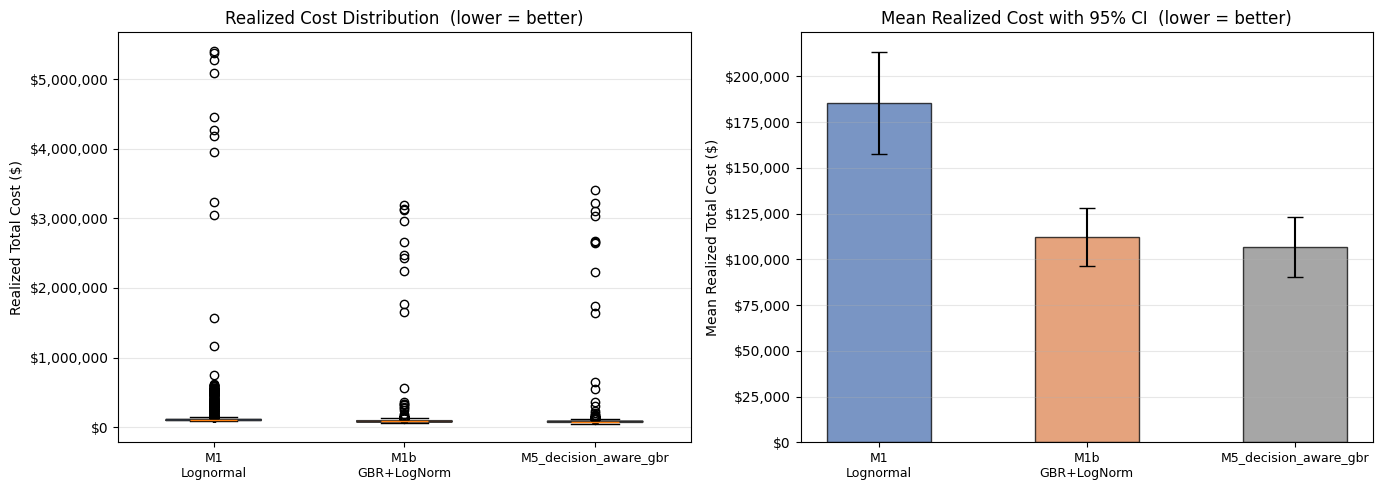

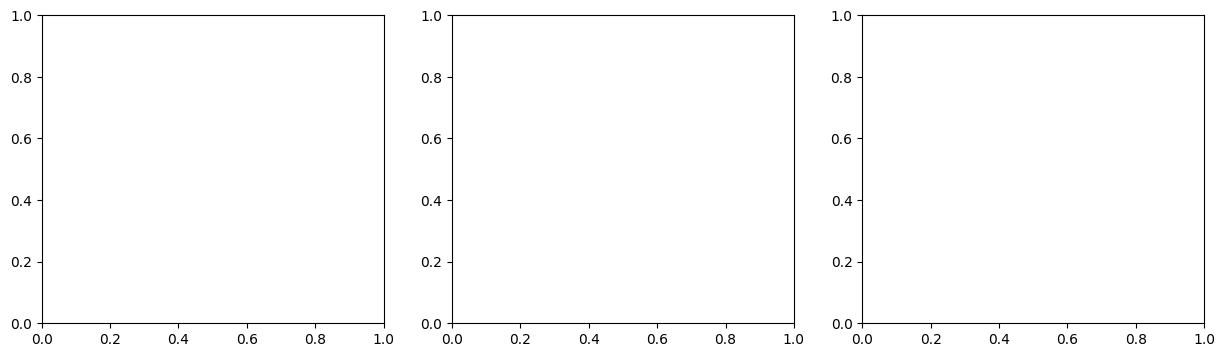

In [28]:
# =============================================================================
# Final Comparison: All Models Side-by-Side
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- 1. Summary table ---
comparison_rows = []
for name, res_df in all_model_results.items():
    s = summarize_results(res_df)
    comparison_rows.append({
        "Model":              name,
        "Mean Total ($)":     f"{s['mean_total']:,.0f}",
        "Std ($)":            f"{s['std_total']:,.0f}",
        "95% CI":             f"[{s['ci_lo']:,.0f}, {s['ci_hi']:,.0f}]",
        "Stage-1 ($)":        f"{s['mean_stage1']:,.0f}",
        "Stage-2 realized ($)": f"{s['mean_stage2']:,.0f}",
        "Shed MW":            f"{s['mean_shed_mw']:.2f}",
        "Frac shed>1 MW":     f"{s['frac_shed_gt1']:.1%}",
    })
cmp_df = pd.DataFrame(comparison_rows).set_index("Model")
print("=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)
print(cmp_df.to_string())

# --- 2. Cost distribution: box + mean-CI bar ---
model_order = list(all_model_results.keys())

# Derived from model_order so counts always match, regardless of which models have run
_label_map = {
    "M1_lognormal":              "M1\nLognormal",
    "M1b_gbr_lognormal":         "M1b\nGBR+LogNorm",
    "M2_ngboost":                "M2\nNGBoost",
    "M4_smart_alpha":            "M4\nSmart-α",
    "M5_meta":                   "M5\nMeta",
    "M6_quantile_duals_fast":    "M6\nQuantile\nDuals",
}
_color_map = {
    "M1_lognormal":              "#4C72B0",
    "M1b_gbr_lognormal":         "#DD8452",
    "M2_ngboost":                "#55A868",
    "M4_smart_alpha":            "#C44E52",
    "M5_meta":                   "#9467BD",
    "M6_quantile_duals_fast":    "#8C564B",
}
labels = [_label_map.get(m, m) for m in model_order]
colors = [_color_map.get(m, "#888888") for m in model_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
ax = axes[0]
data_boxes = [all_model_results[m]["total_realized"].values for m in model_order]
bp = ax.boxplot(data_boxes, patch_artist=True, notch=True, widths=0.5)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_xticks(range(1, len(model_order) + 1))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Realized Total Cost ($)")
ax.set_title("Realized Cost Distribution  (lower = better)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.grid(axis="y", alpha=0.3)

# Mean + 95% CI bar chart
ax2 = axes[1]
summaries = [summarize_results(all_model_results[m]) for m in model_order]
means     = [s["mean_total"] for s in summaries]
errs_lo   = [s["mean_total"] - s["ci_lo"] for s in summaries]
errs_hi   = [s["ci_hi"] - s["mean_total"] for s in summaries]

x = range(len(model_order))
ax2.bar(x, means, color=colors, alpha=0.75, edgecolor="black", width=0.5)
ax2.errorbar(x, means, yerr=[errs_lo, errs_hi],
             fmt="none", color="black", capsize=6, linewidth=1.5)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylabel("Mean Realized Total Cost ($)")
ax2.set_title("Mean Realized Cost with 95% CI  (lower = better)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# --- 3. Alpha variation across the full test set ---
_af = _test_feats.copy()

_af["humidity"]   = df.loc[_af.index, "humidity"]
_af["hour_sin"]   = np.sin(2 * np.pi * _af["hour"] / 24)
_af["hour_cos"]   = np.cos(2 * np.pi * _af["hour"] / 24)
_af["is_peak"]    = ((_af["hour"] >= 16) & (_af["hour"] <= 21)).astype(int)


fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))



In [ ]:
# =============================================================================
# STRESS-TEST EVALUATION: Top 5% Highest Actual Demand
#
# No retraining. All models are evaluated AS-IS on 100 timestamps drawn from
# the top 5th-percentile of actual system load within the held-out test pool.
# These are the hardest cases for any dispatch model — the scenarios where
# forecast errors are costliest and reserve adequacy matters most.
# M4's covariate-conditioned alpha should shine here precisely because
# high temperature / peak-hour conditions reliably push demand above the base
# NGBoost forecast, and the alpha layer was trained to correct for exactly that.
# =============================================================================
import matplotlib.ticker as mticker   # safe re-import in case cell order varies

# --- 1. Identify the top 5% of test pool by actual system load ---
_test_loads = df.loc[test_df.index, 'load_mw']
_p95        = _test_loads.quantile(0.95)
_high_pool  = test_df.loc[_test_loads >= _p95]

print(f"Full test pool:       {len(test_df):,} timestamps")
print(f"95th-pctile load:     {_p95:,.1f} MW")
print(f"High-demand pool:     {len(_high_pool):,} timestamps "
      f"({100*len(_high_pool)/len(test_df):.1f}% of test set)")

_rng_stress       = np.random.default_rng(77)
_n_stress         = min(100, len(_high_pool))
_stress_idx       = _rng_stress.choice(len(_high_pool), size=_n_stress, replace=False)
stress_timestamps = _high_pool.index[np.sort(_stress_idx)]

print(f"Stress-test set:      {_n_stress} timestamps")
print(f"  Mean load (stress): {df.loc[stress_timestamps, 'load_mw'].mean():,.1f} MW")
print(f"  Mean load (random): {df.loc[test_timestamps,   'load_mw'].mean():,.1f} MW")

# --- 2. Rebuild lookup dicts for conditional models over stress_timestamps ---
#        predict_m1 is unconditional — no rebuild needed.
_sf_arr = df.loc[stress_timestamps, FEATS].values   # shared base feature matrix

# M1b: GBR conditional mean
_mu_stress_m1b      = gbr.predict(_sf_arr)
_mu_dict_stress_m1b = dict(zip(stress_timestamps, _mu_stress_m1b))

def predict_m1b_stress(ts):
    mu = _mu_dict_stress_m1b[ts]
    return mu * _BASE_BUS, np.outer(mu * eps_base, _BASE_BUS)

# M2: NGBoost conditional lognormal
_Y_stress_m2 = ngb.pred_dist(_sf_arr)
_med_s_m2    = dict(zip(stress_timestamps, _Y_stress_m2.params['scale']))
_sig_s_m2    = dict(zip(stress_timestamps, _Y_stress_m2.params['s']))

def predict_m2_stress(ts):
    sf_median = float(_med_s_m2[ts])
    sf_sigma  = float(_sig_s_m2[ts])
    mu_log    = np.log(sf_median)
    sf_mean   = np.exp(mu_log + (sf_sigma**2) / 2.0)
    sf_scens  = np.exp(mu_log + sf_sigma * Z_base_m2)
    return sf_mean * _BASE_BUS, np.outer(sf_scens, _BASE_BUS)

# M4: Smart-Alpha — rebuild full alpha feature matrix for stress timestamps
_af_stress = df.loc[stress_timestamps, FEATS].copy()
_Yd_stress = ngb.pred_dist(_af_stress.values)
_af_stress['base_mu']    = _Yd_stress.params['scale']
_af_stress['base_sigma'] = _Yd_stress.params['s']
_af_stress['humidity']   = df.loc[stress_timestamps, 'humidity'].values
_af_stress['hour_sin']   = np.sin(2 * np.pi * _af_stress['hour'] / 24)
_af_stress['hour_cos']   = np.cos(2 * np.pi * _af_stress['hour'] / 24)
_af_stress['is_peak']    = ((_af_stress['hour'] >= 16) &
                             (_af_stress['hour'] <= 21)).astype(int)
_alpha_stress = alpha_model.predict(_af_stress.values)
_mu_s_m4  = dict(zip(stress_timestamps, _af_stress['base_mu'] * _alpha_stress))
_sig_s_m4 = dict(zip(stress_timestamps, _af_stress['base_sigma']))

def predict_m4_stress(ts):
    final_mu   = _mu_s_m4[ts]
    base_sigma = _sig_s_m4[ts]
    mu_log     = np.log(final_mu)
    sf_scens   = np.exp(mu_log + base_sigma * Z_base)
    return final_mu * _BASE_BUS, np.outer(sf_scens, _BASE_BUS)

# --- 3. Evaluate all models on stress set ---
_stress_fns = {
    "M1_lognormal":      predict_m1,
    "M1b_gbr_lognormal": predict_m1b_stress,
    "M2_ngboost":        predict_m2_stress,
    "M4_smart_alpha":    predict_m4_stress,
}

stress_results = {}
for _mname, _pfn in _stress_fns.items():
    print(f"\n>>> [{_mname}] stress-test evaluation ...")
    stress_results[_mname] = evaluate_model(_mname, _pfn, stress_timestamps)

# --- 4. Summary table ---
print("\n" + "=" * 70)
print(f"STRESS-TEST RESULTS  (top 5% demand, n={_n_stress})")
print("=" * 70)
_stress_rows = []
for _nm, _res in stress_results.items():
    _s = summarize_results(_res)
    _stress_rows.append({
        "Model":                _nm,
        "Mean Total ($)":       f"{_s['mean_total']:,.0f}",
        "Std ($)":              f"{_s['std_total']:,.0f}",
        "95% CI":               f"[{_s['ci_lo']:,.0f}, {_s['ci_hi']:,.0f}]",
        "Stage-2 realized ($)": f"{_s['mean_stage2']:,.0f}",
        "Shed MW":              f"{_s['mean_shed_mw']:.2f}",
        "Frac shed>1 MW":       f"{_s['frac_shed_gt1']:.1%}",
    })
print(pd.DataFrame(_stress_rows).set_index("Model").to_string())

print("\nM4 improvement over baselines on high-demand scenarios:")
_m4_mean = summarize_results(stress_results["M4_smart_alpha"])["mean_total"]
for _nm in ["M1_lognormal", "M1b_gbr_lognormal", "M2_ngboost"]:
    _base = summarize_results(stress_results[_nm])["mean_total"]
    _sav  = _base - _m4_mean
    print(f"  vs {_nm:<22}: ${_sav:+,.0f}  ({100*_sav/_base:+.2f}%)")

# --- 5. Side-by-side: random test vs stress test ---
_model_order = list(stress_results.keys())
_labels      = ["M1\nLognormal", "M1b\nGBR+LogNorm", "M2\nNGBoost", "M4\nSmart-\u03b1"]
_colors      = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (rdict, title) in zip(axes, [
    (all_model_results, f"Random test  (n={N_TEST})"),
    (stress_results,    f"High-demand stress test  (n={_n_stress}, top 5%)"),
]):
    _boxes = [rdict[m]["total_realized"].values for m in _model_order]
    _bp    = ax.boxplot(_boxes, patch_artist=True, notch=True, widths=0.5)
    for patch, color in zip(_bp["boxes"], _colors):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_xticks(range(1, len(_model_order) + 1))
    ax.set_xticklabels(_labels, fontsize=9)
    ax.set_ylabel("Realized Total Cost ($)")
    ax.set_title(title)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Random vs High-Demand Stress Test  (lower = better)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

Full test pool:       14,396 timestamps
95th-pctile load:     35,650.8 MW
High-demand pool:     720 timestamps (5.0% of test set)
Stress-test set:      100 timestamps
  Mean load (stress): 40,734.1 MW
  Mean load (random): 24,752.7 MW


NameError: name 'ngb' is not defined

In [29]:
# =============================================================================
# Oracle (Perfect Foresight) — Lower Bound on Realized Cost
#
# This model cheats: it uses the actual realized demand as both its point
# prediction AND its single scenario.  Stage 1 is therefore solved with
# exact knowledge of what will happen, giving the best possible first-stage
# commitment.  Stage 2 recourse cost should be near zero (no surprise).
# The result is a theoretical lower bound for all other models.
# =============================================================================

def predict_oracle(ts):
    """Perfect-foresight oracle: predict exactly the realized demand."""
    Pd_actual = pd_actual_at(ts)
    # Single scenario = the exact realized demand vector
    node_scen = Pd_actual.reshape(1, -1)
    return Pd_actual, node_scen

print(">>> Evaluating Oracle (perfect foresight) over test set...")
results_oracle = evaluate_model("Oracle", predict_oracle, test_timestamps)

print("Oracle summary:")
print(summarize_results(results_oracle).to_string())

# Register in the shared results dict so the final comparison cells can pick it up
all_model_results["Oracle"] = results_oracle


>>> Evaluating Oracle (perfect foresight) over test set...


Eval Oracle:   0%|          | 0/1000 [00:00<?, ?it/s]/var/folders/nn/n3_8rlvx6h9bxwg2t6d_0xth0000gn/T/ipykernel_74616/1379236281.py:110: RuntimeWarning: Chained matrix multiplications of MVars is inefficient, collect numeric terms first when building expressions
  _G_bus_sp @ Pg_rt_s + self.G_shed[s, :] - self.G_curt[s, :] - _A_inc_sp.T @ Pe2[s, :] == np.zeros(N_BUS),
Eval Oracle: 100%|██████████| 1000/1000 [00:01<00:00, 984.84it/s] 

Oracle summary:
n                  1000.000000
mean_total       103852.370803
std_total        252249.512795
ci_lo             88199.106583
ci_hi            119505.635023
mean_stage1       79346.106396
mean_stage2       24506.264407
mean_shed_mw          2.448741
mean_curt_mw          0.018951
mean_ramp_mw          0.006587
frac_shed_gt1         0.012000
